# Packages 

In [49]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize

# Time series
from sklearn.model_selection import TimeSeriesSplit

# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm



# utilities

In [50]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q

In [51]:
def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    T = len(scores)
    
    # Define learning rates
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    observed_coverages_decaying = (scores <= q_decaying).astype(int)


    # Compute long-run coverage
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)

    return {
        "T":T,
        "q_decaying": q_decaying,
        "observed_coverages_decaying": observed_coverages_decaying,
        "LRC_decaying": LRC_decaying,

    }

In [52]:
def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    #  Long-run coverage 
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    plt.axhline(y= (1 - alpha), linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

In [53]:
# COMA 

def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge/hedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

# smooth
def smooth_series(series, window=500):
    return np.convolve(series, np.ones(window)/window, mode='valid')

In [54]:
# Simple average ensemble 

def simple_average_ensemble(predictions):
    """
    Simple average ensemble of multiple model predictions.

    Parameters:
        predictions (list of np.array): List of prediction arrays from different models.

    Returns:
        np.array: Ensemble predictions obtained by averaging.
    """
    return np.mean(predictions, axis=0)

# ELEC2

In [55]:
elec = pd.read_csv("elec2.csv")
elec.head()


def trim_constant_prefix(df, col="transfer"):
    x = df[col].to_numpy()
    first_val = x[0]

    idx = np.where(x != first_val)[0]
    if len(idx) == 0:
        raise ValueError(f"{col} is constant everywhere")

    const_ind = idx[0] 
    return df.iloc[const_ind:].reset_index(drop=True)

elec = trim_constant_prefix(elec, col="transfer")
elec = trim_constant_prefix(elec, col="transfer")
elec = elec.iloc[:, 3:8]
# create lag matrix
k = 6
x = elec["transfer"].to_numpy()
lag_raw = np.column_stack([x[i:len(x)-k+i+1] for i in range(k)])
elec_lag = lag_raw[:, ::-1]
elec_lag = elec_lag[:-1, :]
# delete the first 6 obs.
elec = elec.iloc[6:].reset_index(drop=True)
# create outcome and covariates
elec_y = elec["transfer"].to_numpy()
elec_x = elec.iloc[:, 0:4].to_numpy()

In [56]:
def get_preds(Y, X, tinit=50):

    Y = np.asarray(Y)
    X = np.asarray(X)
    T = len(Y)
    preds = []

    for t in range(tinit + 1, T + 1): 
        train_end = t - 1          
        pred_idx = t - 1   

        model = LinearRegression(fit_intercept=True)
        model.fit(X[:train_end], Y[:train_end])
        preds.append(model.predict(X[pred_idx:pred_idx+1])[0])

    return np.array(preds)

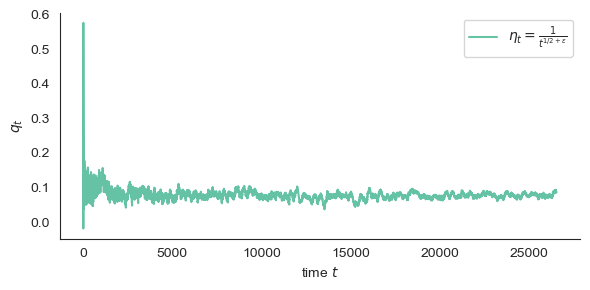

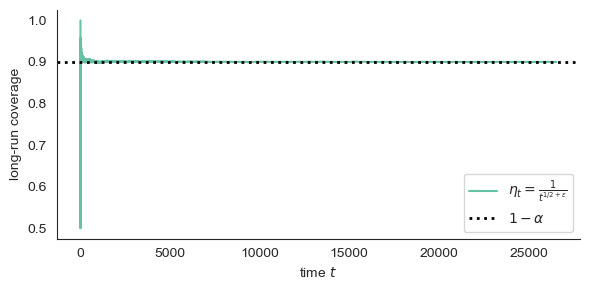

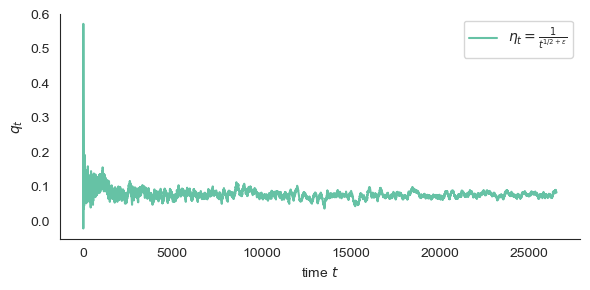

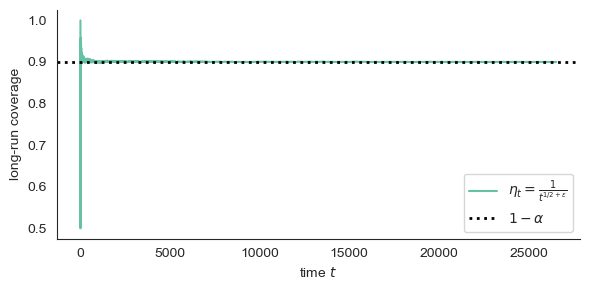

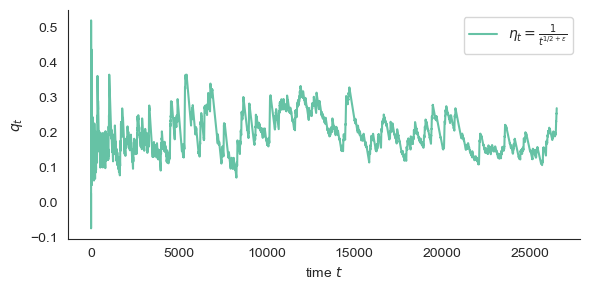

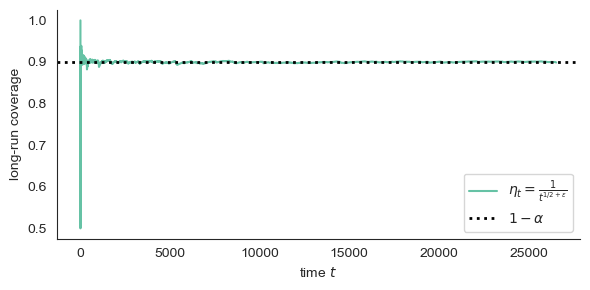

In [57]:
seed = 42
np.random.seed(seed)
y_true_aligned = elec_y[1000:]
# AR(2)
y_pred_ar2 = get_preds(elec_y, elec_lag[:, :2], tinit=1000)
ar2_met = compute_coverage_metrics(y_true_aligned, y_pred_ar2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(ar2_met, alpha=0.1, W=1000)
CI_ar2_decaying = ar2_met['q_decaying'] * 2
# AR(2) + covariate
X_ar2_cov = np.column_stack([elec_lag[:, :2], elec_x[:, 0]])
y_pred_ar2_cov = get_preds(elec_y, X_ar2_cov, tinit=1000)
ar2_cov_met = compute_coverage_metrics(y_true_aligned, y_pred_ar2_cov, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(ar2_cov_met, alpha=0.1, W=1000)
CI_ar2_cov_decaying = ar2_cov_met['q_decaying'] * 2
# Only covariate
y_pred_cov = get_preds(elec_y, elec_x, tinit=1000)
cov_met = compute_coverage_metrics(y_true_aligned, y_pred_cov, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(cov_met, alpha=0.1, W=1000)
CI_cov_decaying = cov_met['q_decaying'] * 2

In [58]:
print(f'mean coverage for covarite is:', np.mean(cov_met['observed_coverages_decaying']))
print(f'mean coverage for ar2+cov is:', np.mean(ar2_cov_met['observed_coverages_decaying']))
print(f'mean coverage for ar is:', np.mean(ar2_met['observed_coverages_decaying']))

mean coverage for covarite is: 0.8987041362163791
mean coverage for ar2+cov is: 0.8999849318164695
mean coverage for ar is: 0.8999472613576434


In [59]:
print("elec_y:", len(elec_y))
print("y_true_aligned:", len(y_true_aligned))
print("y_pred_ar2:", len(y_pred_ar2))
print("ar2_met['q_decaying']:", len(ar2_met["q_decaying"]))
print("ar2_met['LRC_decaying']:", len(ar2_met["LRC_decaying"]))

elec_y: 27546
y_true_aligned: 26546
y_pred_ar2: 26546
ar2_met['q_decaying']: 26546
ar2_met['LRC_decaying']: 26546


In [60]:

from scipy.stats import gaussian_kde

def plot_density(y_true, y_pred, title, label_pred):
    kde_pred = gaussian_kde(y_pred)

    x_min = min(y_true.min(), y_pred.min())
    x_max = max(y_true.max(), y_pred.max())
    x_grid = np.linspace(x_min, x_max, 500)

    plt.figure(figsize=(6, 4))
    plt.plot(x_grid, kde_pred(x_grid), label=label_pred, linewidth=2, linestyle="--")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Simple Average 

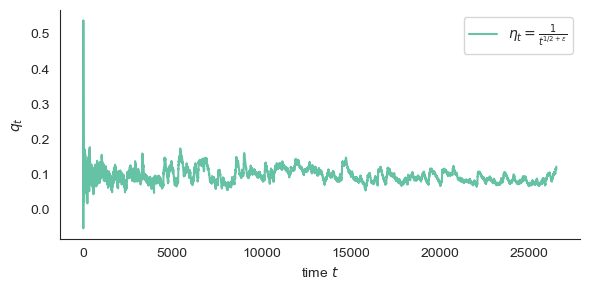

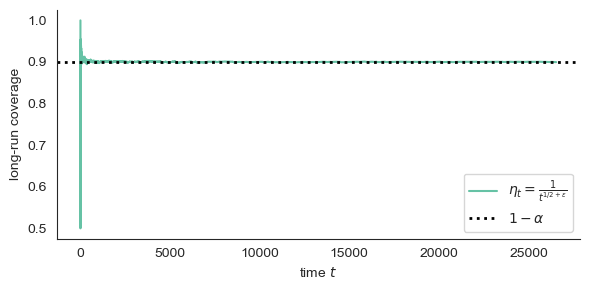

0.09530442164407661


In [36]:
y_sa_pred = simple_average_ensemble([y_pred_ar2, y_pred_ar2_cov, y_pred_cov])
results_sa = compute_coverage_metrics(y_true_aligned, y_sa_pred, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_sa, alpha=0.1, W=1000)
print(np.mean(results_sa['q_decaying']))
CI_sa_decaying = results_sa['q_decaying'] * 2

# Super Learner 

First meta-learner weights: [0.49751288 0.49587194 0.00661518]


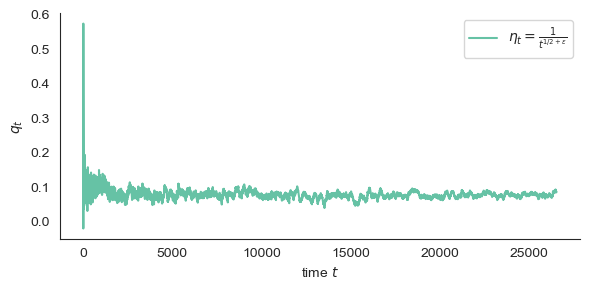

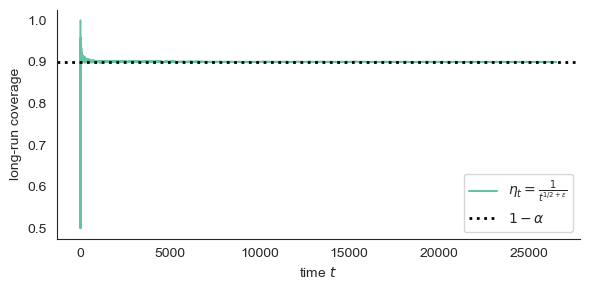

mean coverage for Super Learner is: 0.8999472613576434


In [37]:

tinit = 1000

def online_preds_for_indices(Y, X, idx_list, start_fit=0):
    """
    For each t in idx_list:
      fit on [start_fit .. t-1] and predict at t.
    Returns preds in the same order as idx_list.
    """
    preds = np.empty(len(idx_list), dtype=float)
    for j, t in enumerate(idx_list):
        if t <= start_fit:
            preds[j] = np.nan
            continue
        model = LinearRegression().fit(X[start_fit:t], Y[start_fit:t])  # up to t-1
        preds[j] = model.predict(X[t:t+1])[0]
    return preds


def base_preds_fold(train_idx_full, val_idx_full, elec_y, elec_lag, elec_x, tinit=1000):
    start_fit = 0 
    
    X_ar2 = elec_lag[:, :2]
    X_ar2_cov = np.column_stack([elec_lag[:, :2], elec_x[:, 0]])
    X_cov = elec_x

    p1 = online_preds_for_indices(elec_y, X_ar2,     val_idx_full, start_fit=start_fit)
    p2 = online_preds_for_indices(elec_y, X_ar2_cov, val_idx_full, start_fit=start_fit)
    p3 = online_preds_for_indices(elec_y, X_cov,     val_idx_full, start_fit=start_fit)

    return np.column_stack([p1, p2, p3])

def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    init_phi = np.ones(X.shape[1]) / X.shape[1]
    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2
    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

def super_learner_elec(elec_y, elec_lag, elec_x, tinit=1000, n_splits=5):
    y_true = elec_y[tinit:]
    meta_features = np.full((len(y_true), 3), np.nan)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    # Cross Validation 
    for fold, (train_idx, val_idx) in enumerate(tscv.split(y_true)):
        train_idx_full = train_idx + tinit
        val_idx_full   = val_idx + tinit

        preds_val = base_preds_fold(train_idx_full, val_idx_full, elec_y, elec_lag, elec_x)

        meta_features[val_idx, :] = preds_val 

    valid_rows = ~np.isnan(meta_features).any(axis=1)
    X_meta_cv = meta_features[valid_rows]
    y_meta_cv = y_true[valid_rows]

    # meta-learner weight
    meta_weights = optimize_weights(X_meta_cv, y_meta_cv)
    print("First meta-learner weights:", meta_weights)
    # Retrain on the full dataset 
    y_pred_ar2 = get_preds(elec_y, elec_lag[:, :2], tinit=tinit)
    y_pred_ar2_cov = get_preds(elec_y, np.column_stack([elec_lag[:, :2], elec_x[:, 0]]), tinit=tinit)
    y_pred_cov = get_preds(elec_y, elec_x, tinit=tinit)

    X_meta_full = np.column_stack([y_pred_ar2, y_pred_ar2_cov, y_pred_cov])

    T_test = len(y_true)
    super_preds = np.zeros(T_test)
    weights_hist = np.zeros((T_test, 3))

    w = meta_weights.copy()
    # NNLS with online updating 
    for t in range(T_test):
        if t > 0:
            w = optimize_weights(X_meta_full[:t], y_true[:t])
        super_preds[t] = X_meta_full[t] @ w
        weights_hist[t] = w

    return super_preds, weights_hist

super_preds, weights_hist = super_learner_elec(elec_y, elec_lag, elec_x, tinit=1000, n_splits=3)

super_met = compute_coverage_metrics(
    elec_y[tinit:], super_preds,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(super_met, alpha=0.1, W=1000)
CI_sl_decaying = super_met['q_decaying'] * 2
print(f'mean coverage for Super Learner is:', np.mean(super_met['observed_coverages_decaying']))

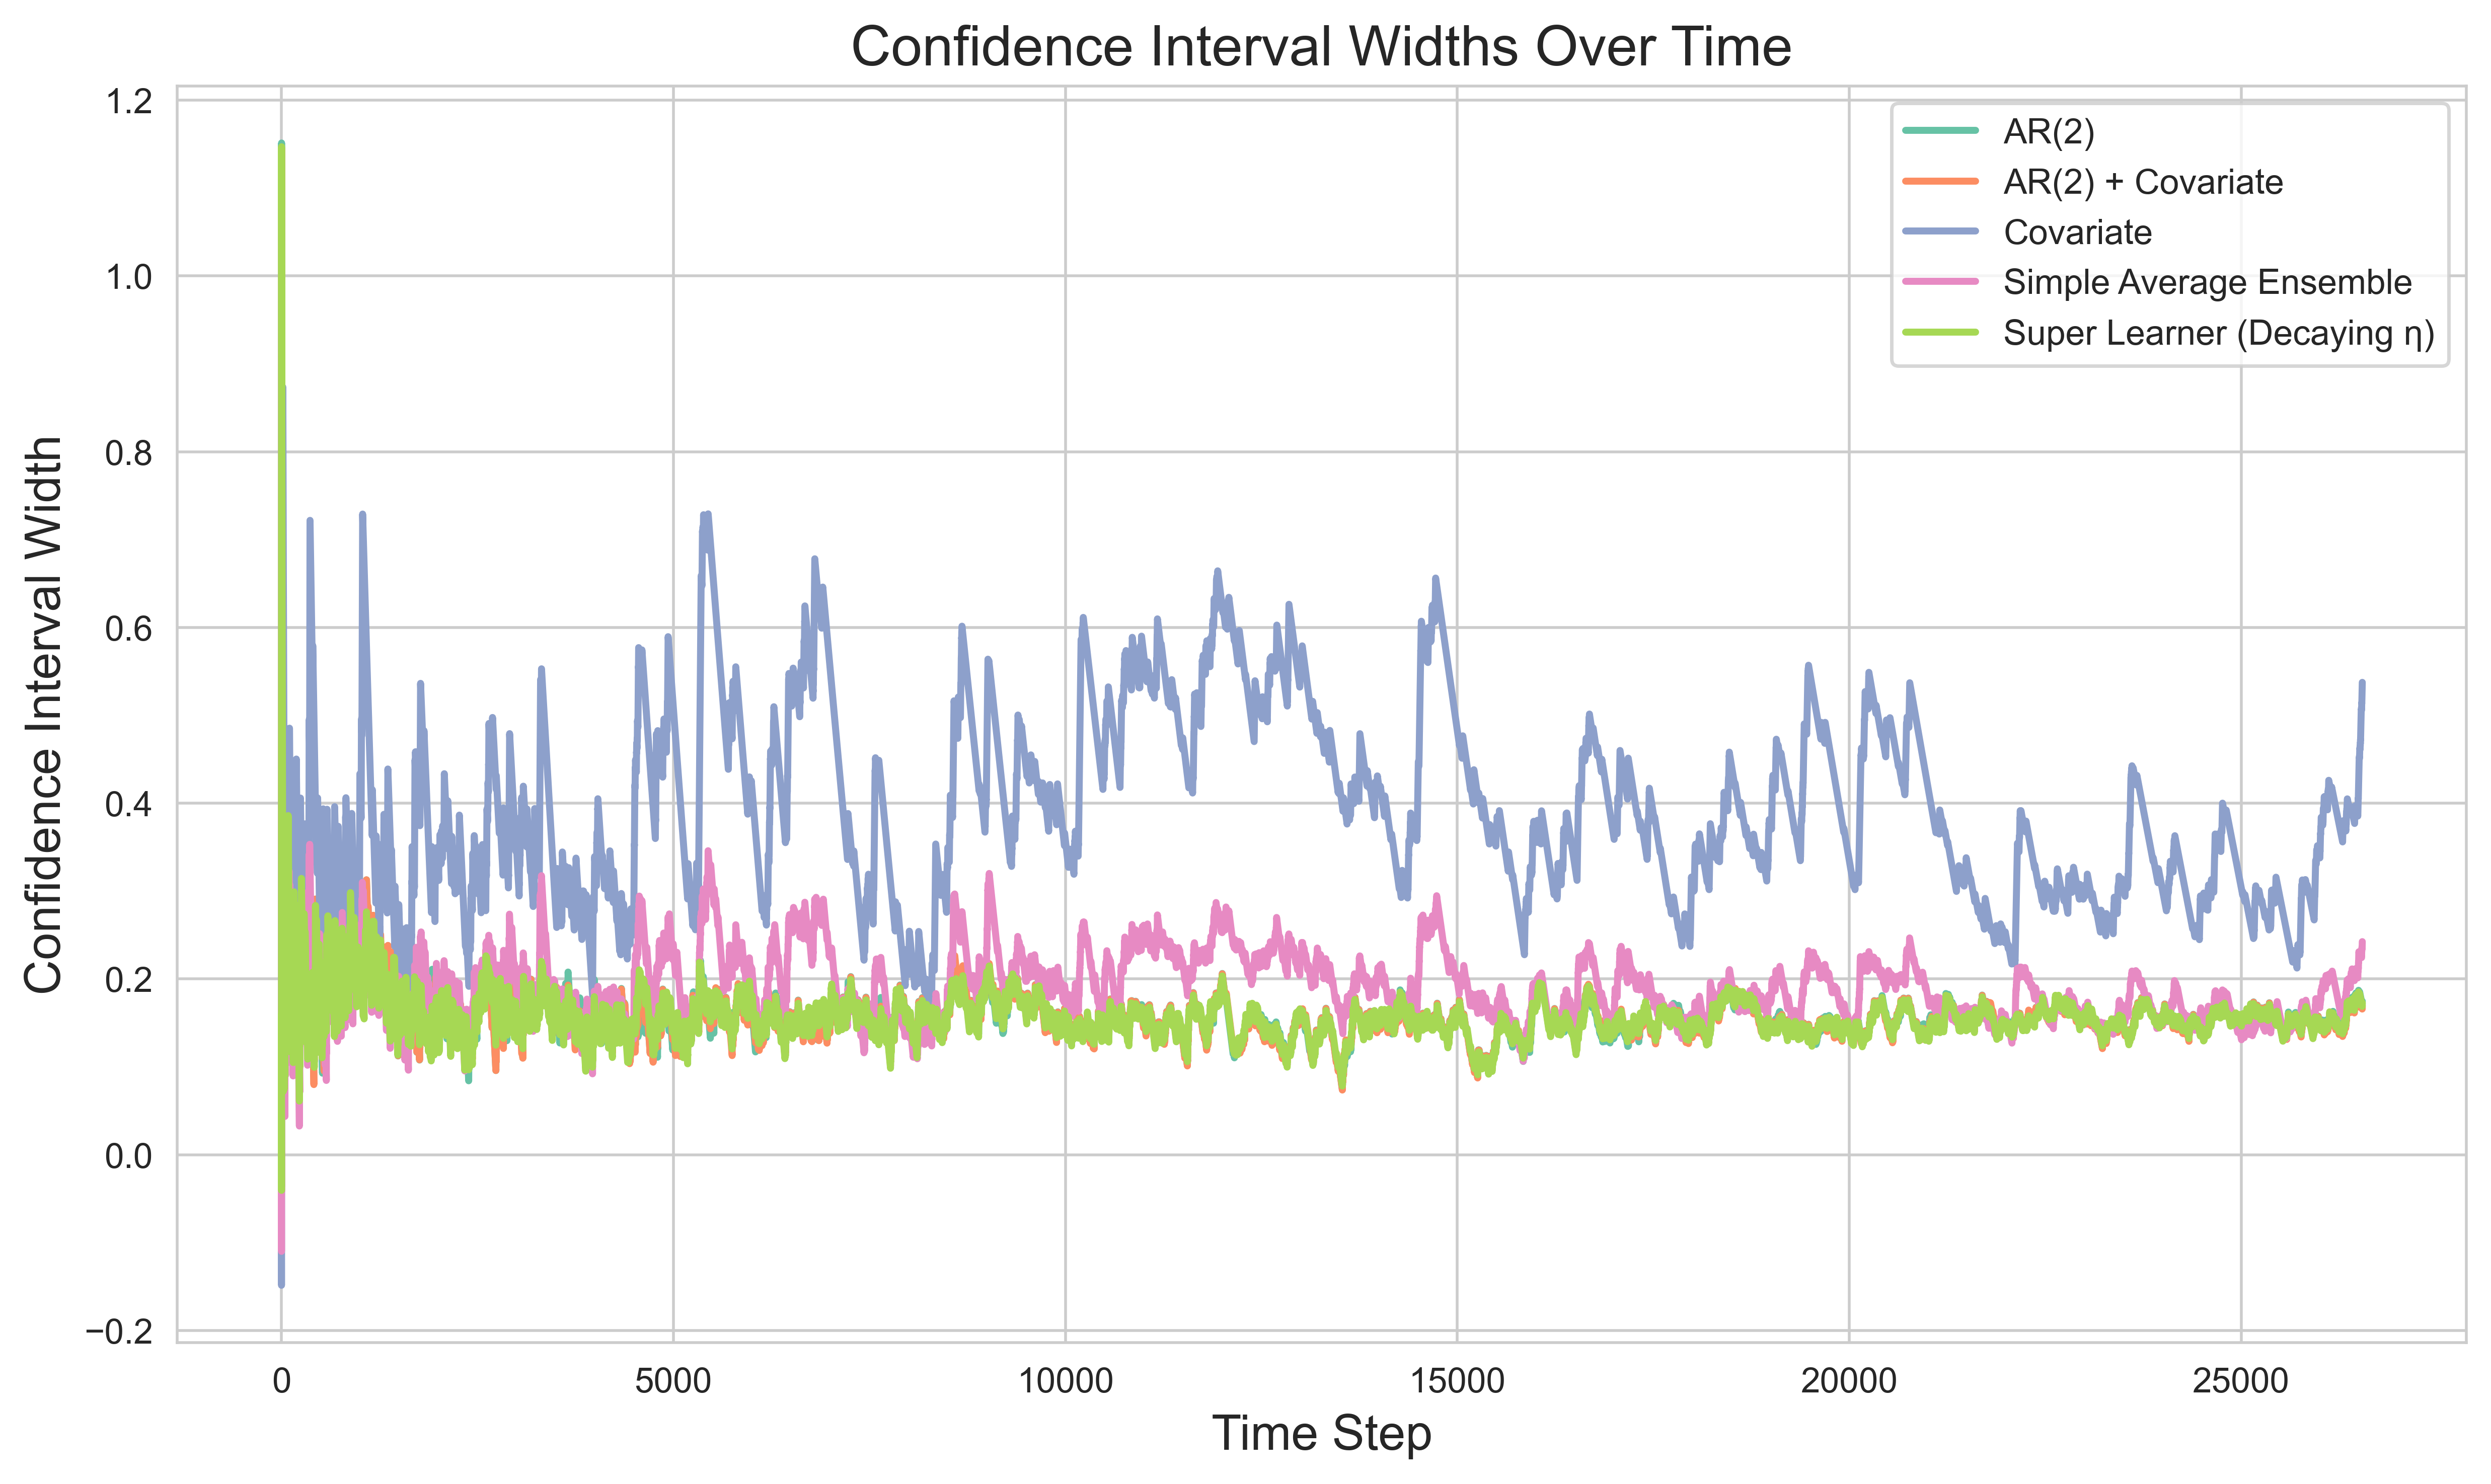

In [38]:
## line comparison plot 

n = len(CI_cov_decaying)
x = list(range(n))  # n is the number of CI values
plt.figure(figsize=(10, 6), dpi=500)
sns.set_style("whitegrid")
plt.plot(x, CI_ar2_decaying[-n:], label='AR(2)', linewidth=2)
plt.plot(x, CI_ar2_cov_decaying[-n:], label='AR(2) + Covariate', linewidth=2)
plt.plot(x, CI_cov_decaying, label='Covariate', linewidth=2)
plt.plot(x, CI_sa_decaying[-n:], label='Simple Average Ensemble', linewidth=2)
plt.plot(x, CI_sl_decaying[-n:], label='Super Learner (Decaying η)', linewidth=2)

plt.title('Confidence Interval Widths Over Time', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Confidence Interval Width', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


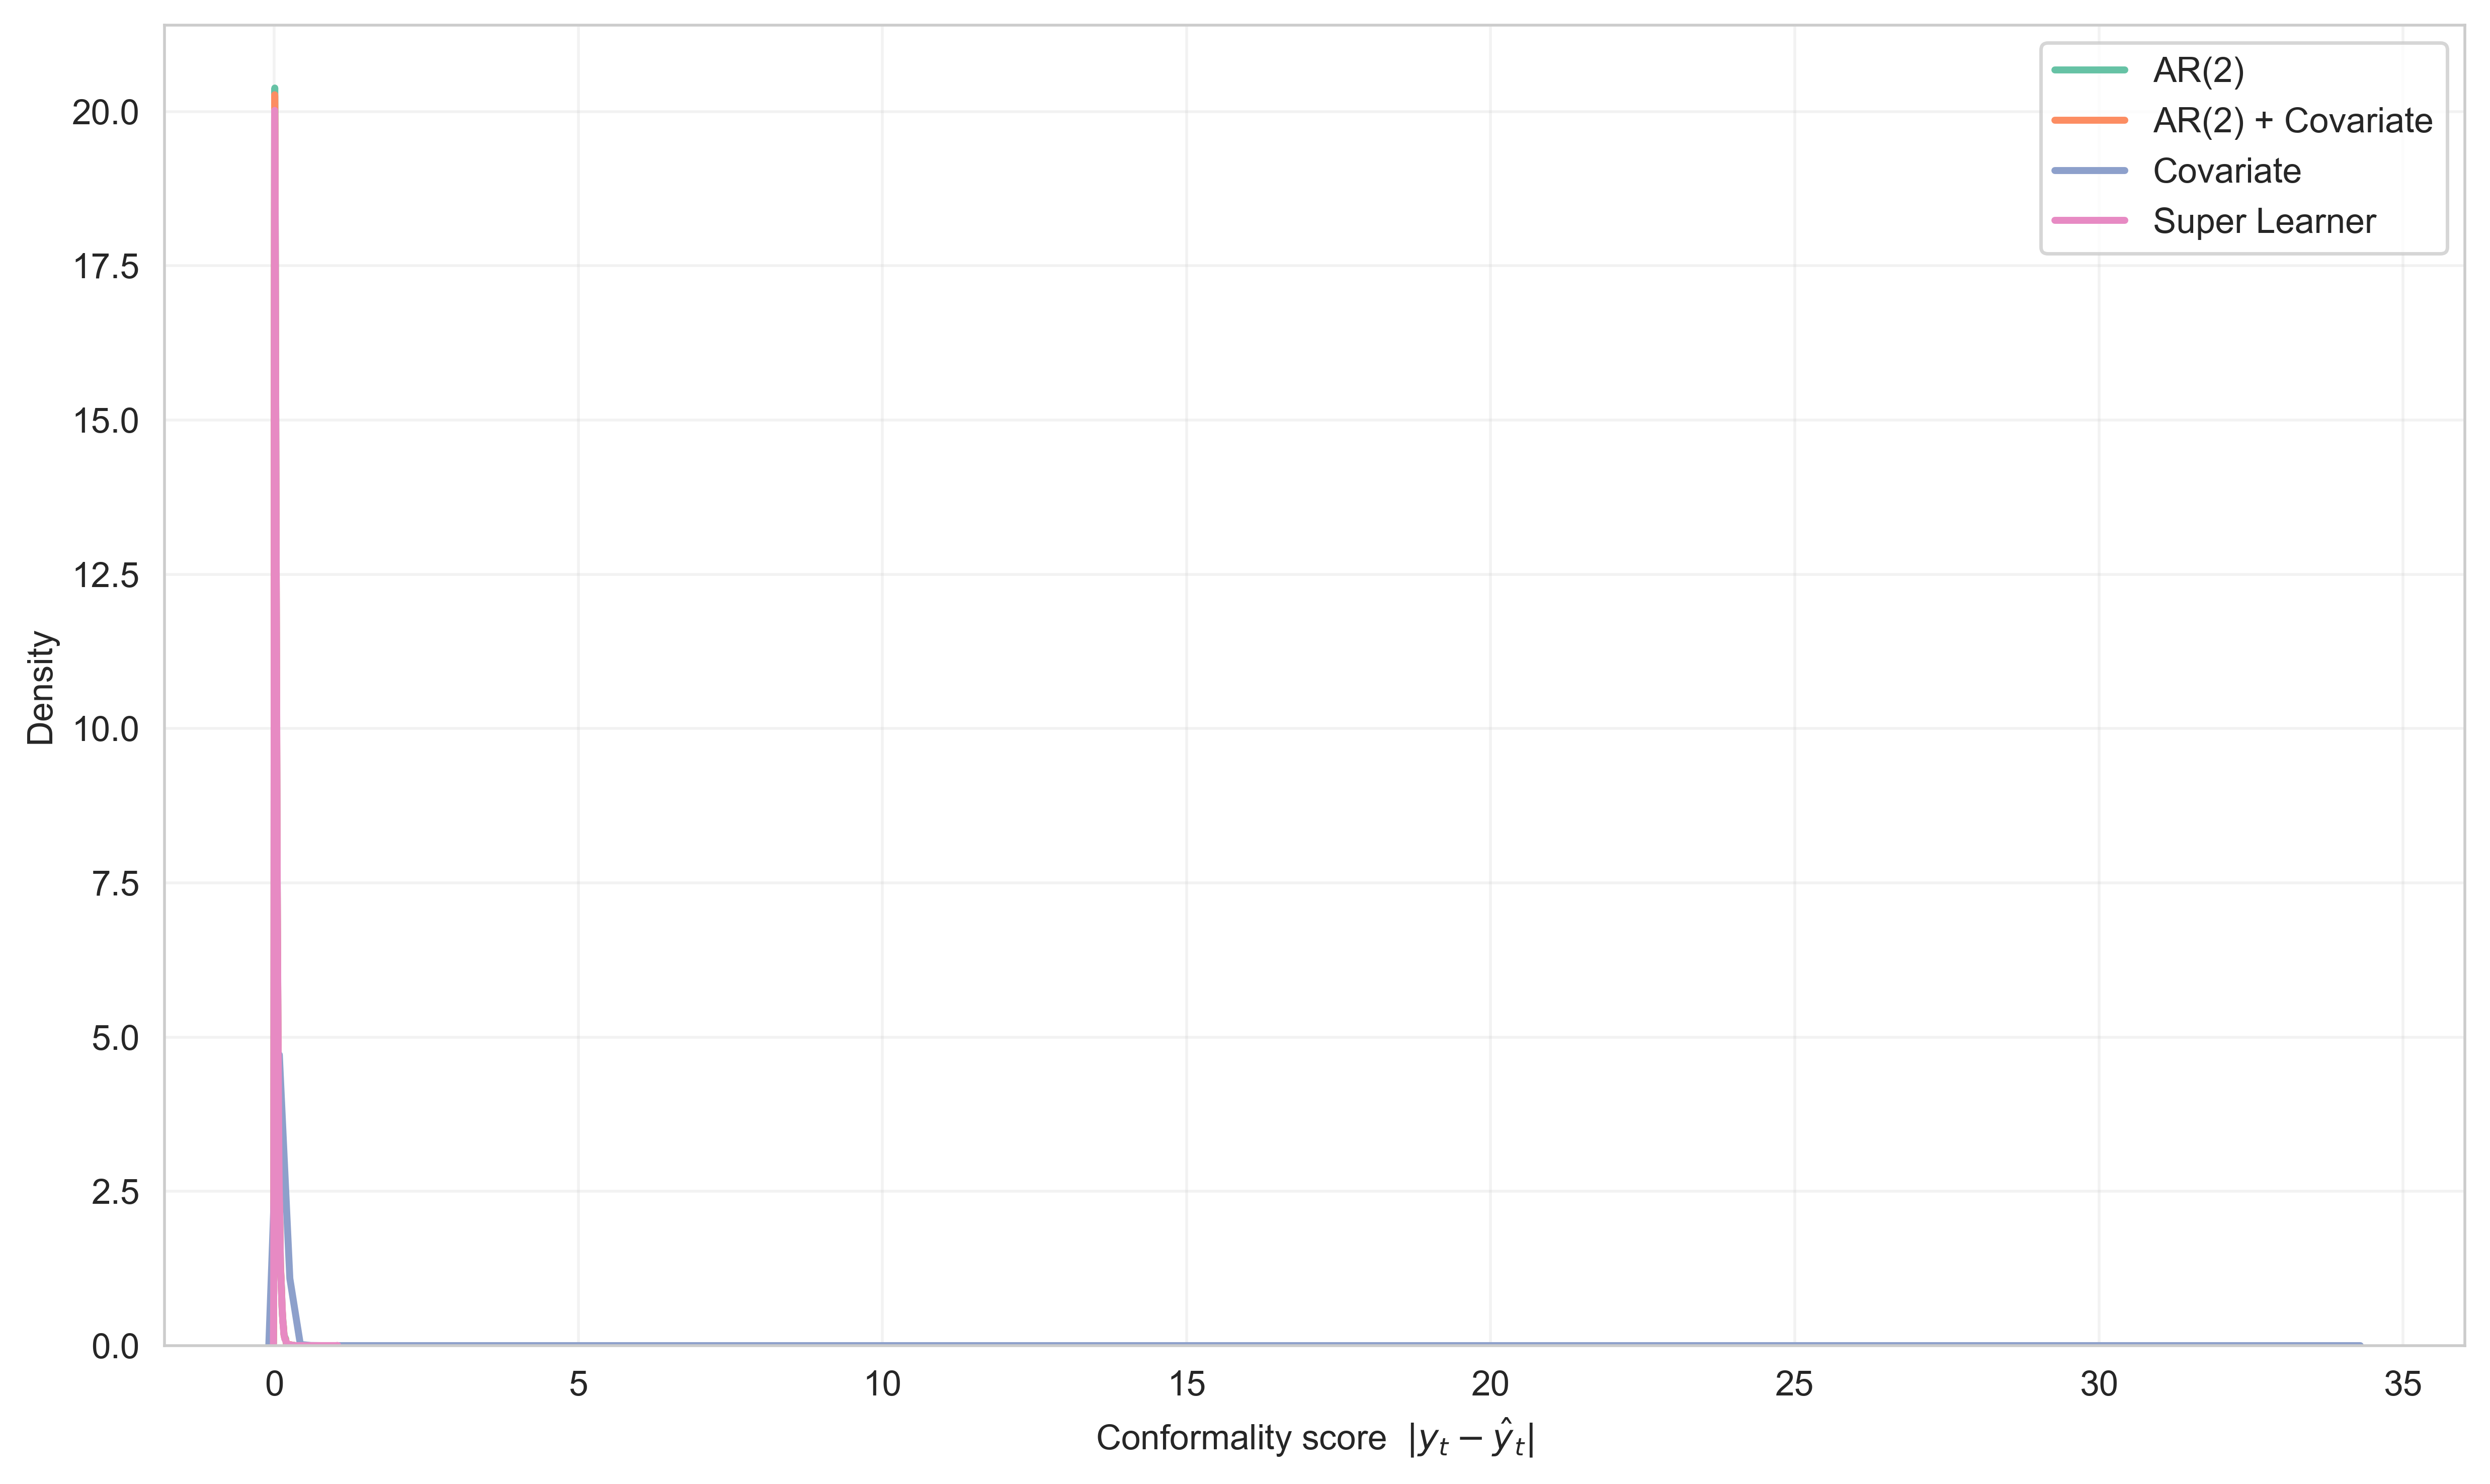

In [39]:

# Conformality scores
score_ar2 = np.abs(y_true_aligned - y_pred_ar2)
score_ar2_cov = np.abs(y_true_aligned - y_pred_ar2_cov)
score_cov = np.abs(y_true_aligned - y_pred_cov)
score_sl = np.abs(y_true_aligned - super_preds)

plt.figure(figsize=(10, 6), dpi=500)

sns.kdeplot(score_ar2, label="AR(2)", linewidth=2)
sns.kdeplot(score_ar2_cov, label="AR(2) + Covariate", linewidth=2)
sns.kdeplot(score_cov, label="Covariate", linewidth=2)
sns.kdeplot(score_sl, label="Super Learner", linewidth=2)

plt.xlabel("Conformality score  $|y_t - \hat y_t|$")
plt.ylabel("Density")
#plt.title("ELEC2: Density of Conformality Scores")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("elec2_score_density.png", dpi=500, bbox_inches="tight")
plt.show()

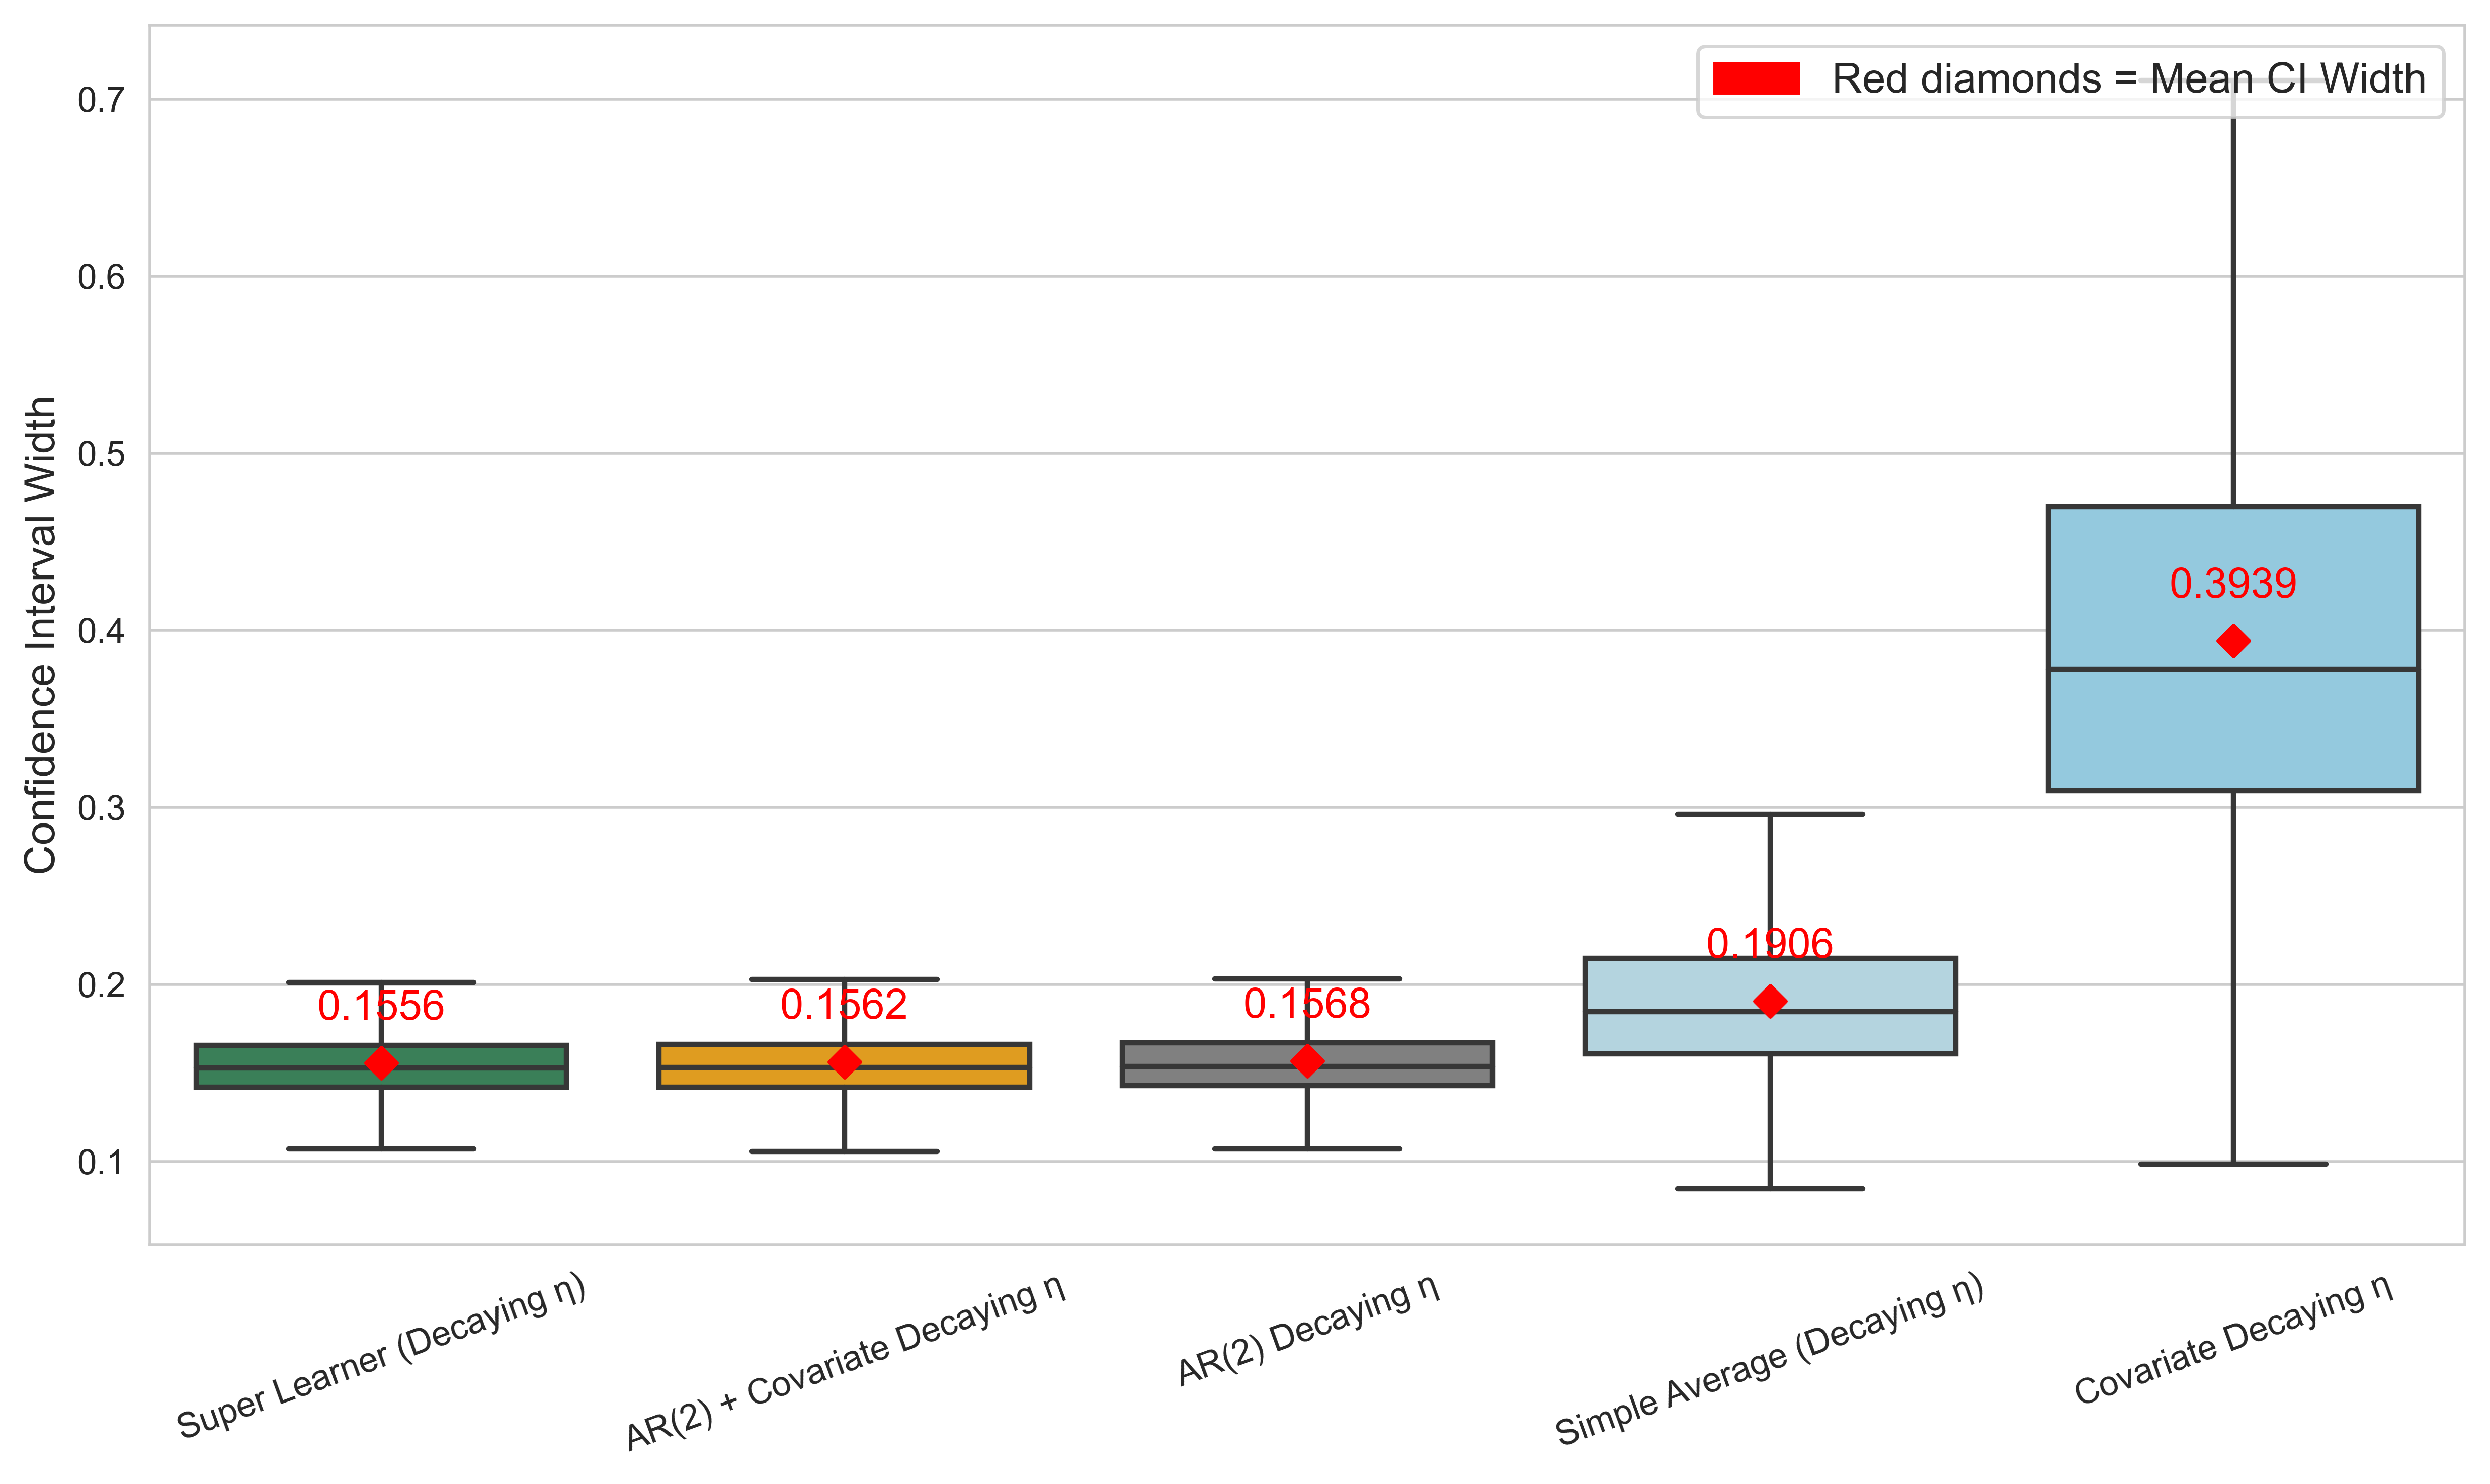

In [78]:

data_dict = {
    "AR(2) Decaying η": CI_ar2_decaying,
    "AR(2) + Covariate Decaying η": CI_ar2_cov_decaying,
    "Covariate Decaying η": CI_cov_decaying,
    "Simple Average (Decaying η)": CI_sa_decaying,
    "Super Learner (Decaying η)": CI_sl_decaying
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6), dpi=500)
sns.set_style("whitegrid")
palette = {
    "AR(2) Decaying η": "gray",
    "AR(2) + Covariate Decaying η": "orange",
    "Covariate Decaying η": "skyblue",
    "Simple Average (Decaying η)": "lightblue",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.4f}",
            ha='center', va='bottom', fontsize=12, color="red")

mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

#plt.title("ELEC2: Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("elec2_CI_comparison.png", dpi=500, bbox_inches="tight")
plt.show()



# COMA 

## Adahedge

Mean randomized coverage: 0.8995705567693815
Mean CI width — COMA: 0.15599116786157102
Mean CI width — Super Learner: 0.15560481919835092


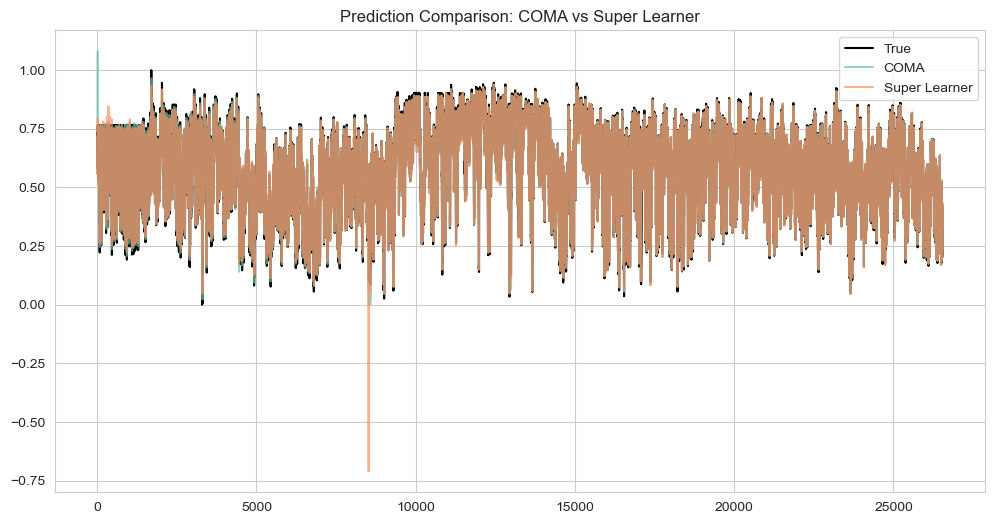

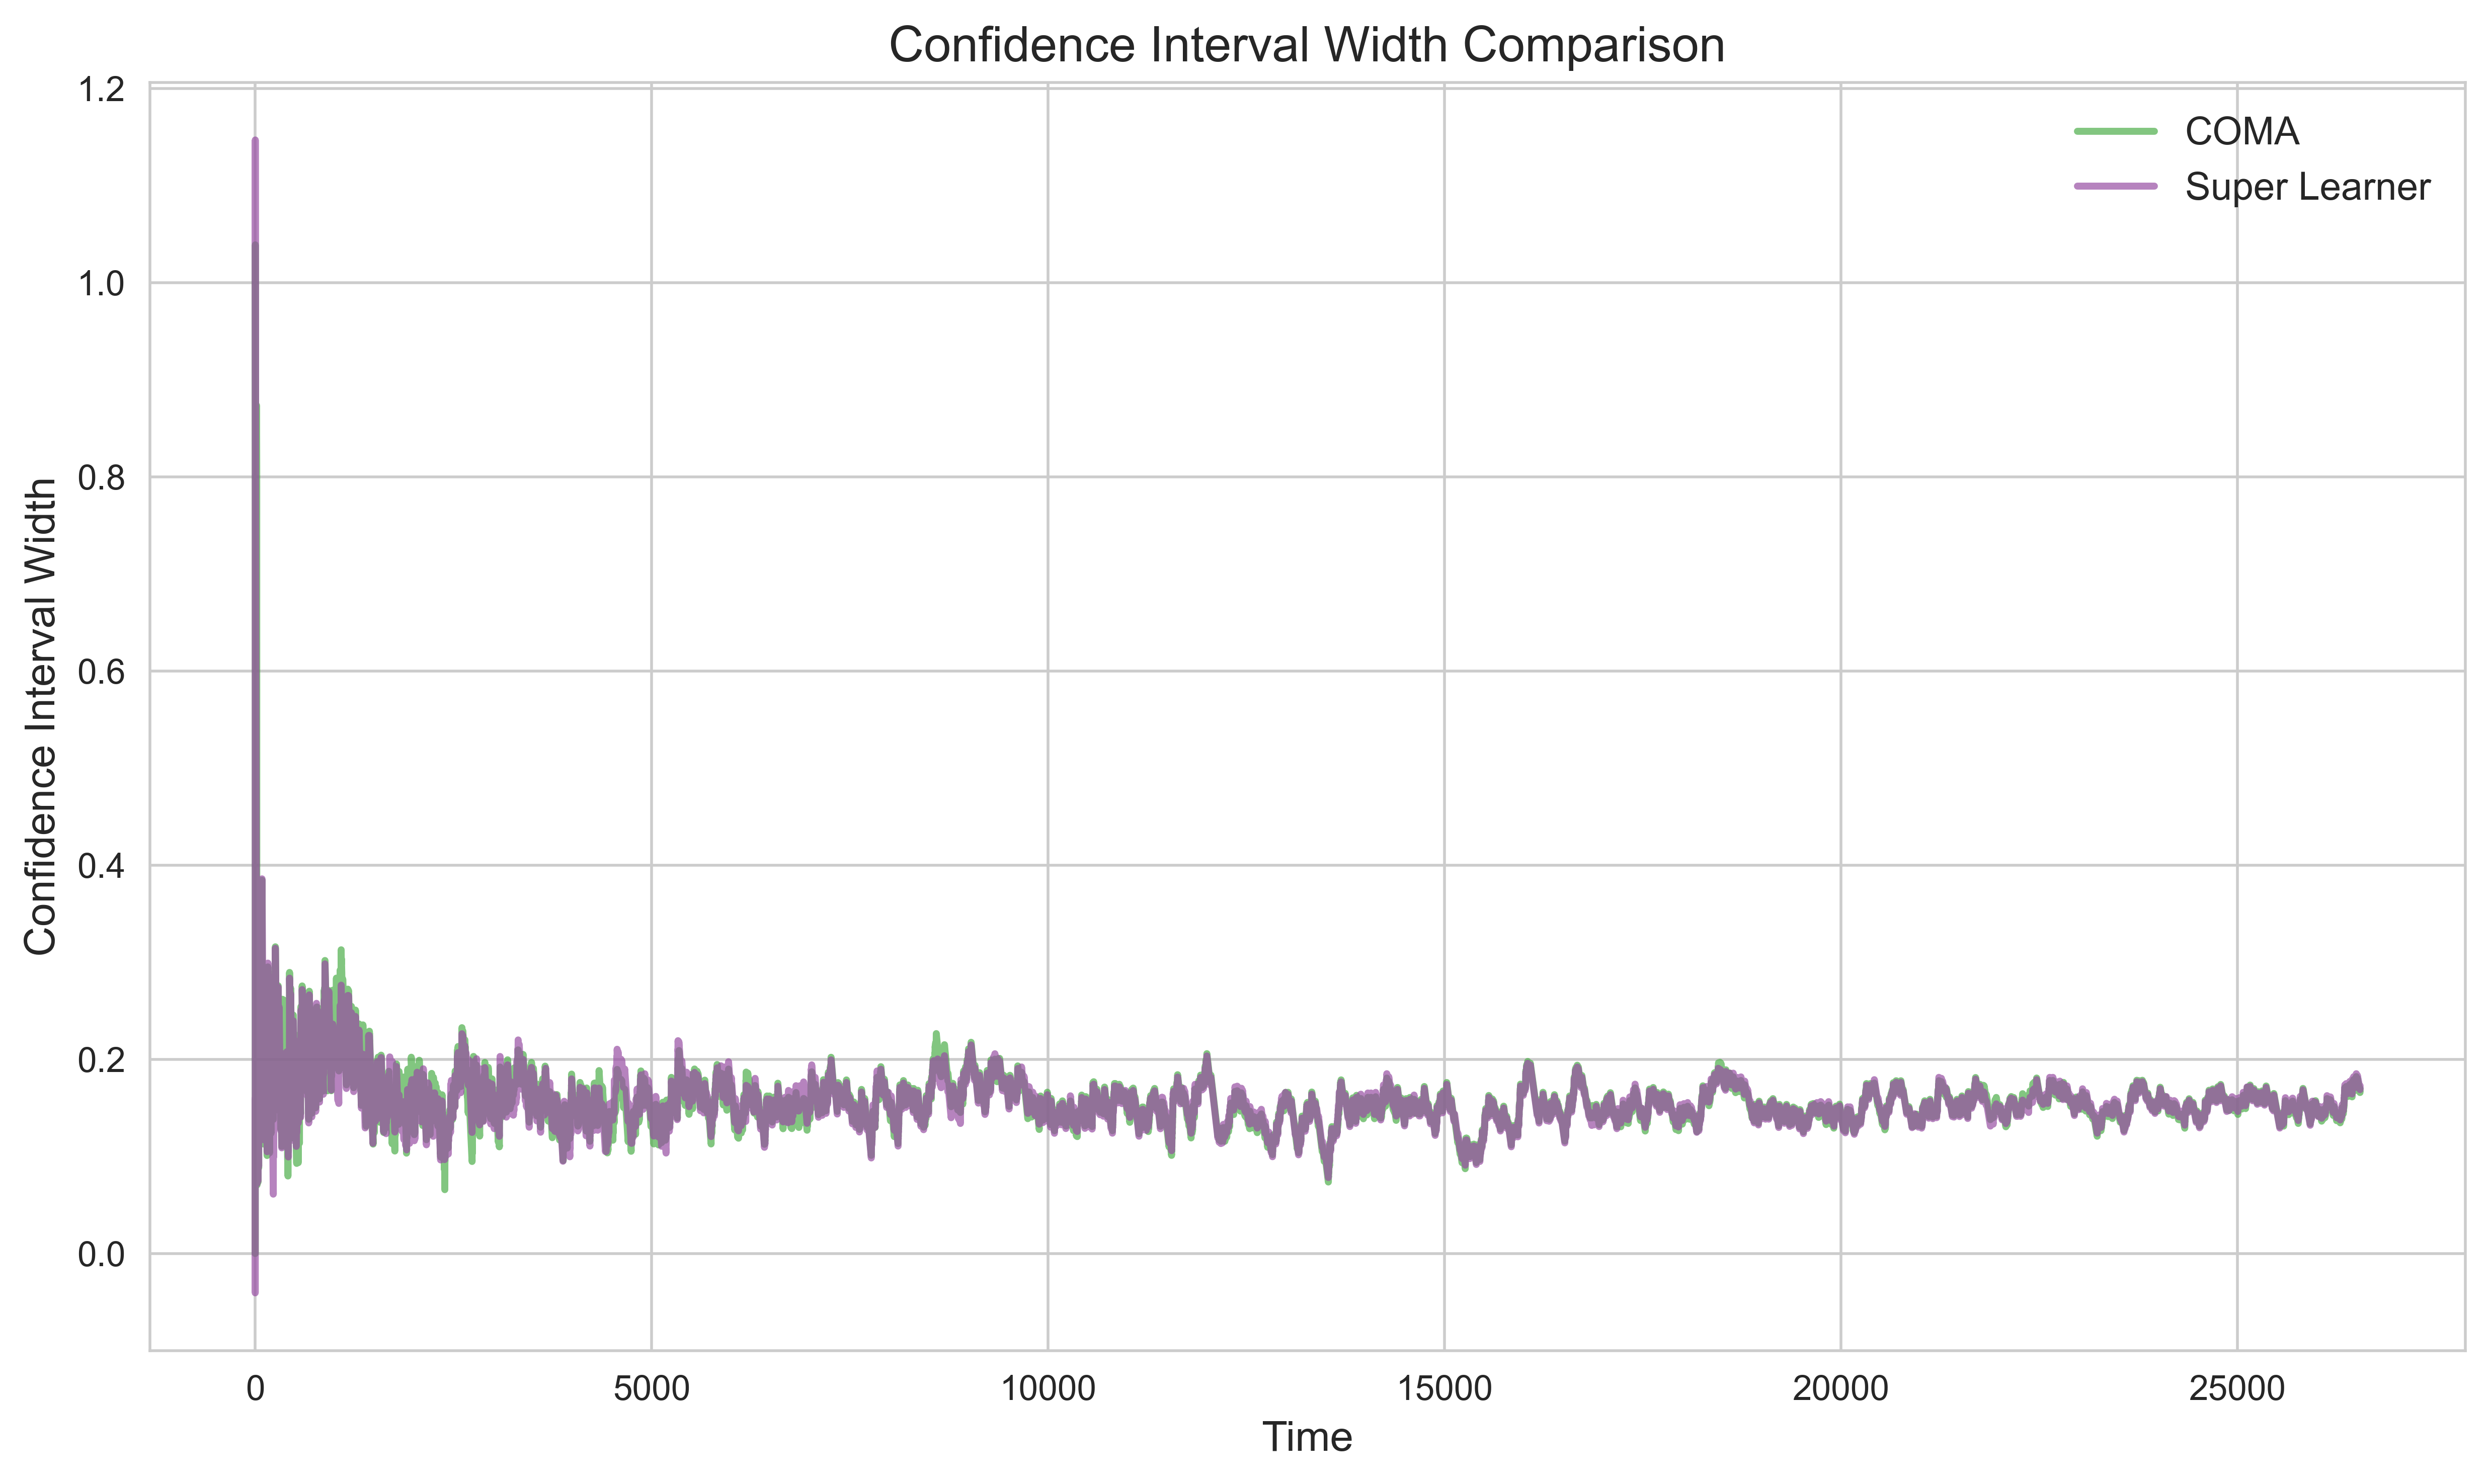

In [96]:

min_len = min(
    len(ar2_met['q_decaying']),
    len(ar2_cov_met['q_decaying']),
    len(cov_met['q_decaying']),
    len(CI_sl_decaying),
    len(elec_y[tinit:])  # already aligned after tinit
)
ci_matrix = np.column_stack([
    CI_ar2_decaying[-min_len:],       # AR(2)
    CI_ar2_cov_decaying[-min_len:],   # AR(2) + covariate
    CI_cov_decaying[-min_len:]        # Covariate only
])

adahedAlg = adahedge(loss_matrix=ci_matrix)
weights_plain = adahedAlg["weights"]
intervals_ar2 = np.column_stack([
    y_pred_ar2[-min_len:] - ar2_met['q_decaying'][-min_len:],
    y_pred_ar2[-min_len:] + ar2_met['q_decaying'][-min_len:]
])

intervals_ar2_cov = np.column_stack([
    y_pred_ar2_cov[-min_len:] - ar2_cov_met['q_decaying'][-min_len:],
    y_pred_ar2_cov[-min_len:] + ar2_cov_met['q_decaying'][-min_len:]
])

intervals_cov = np.column_stack([
    y_pred_cov[-min_len:] - cov_met['q_decaying'][-min_len:],
    y_pred_cov[-min_len:] + cov_met['q_decaying'][-min_len:]
])

intervals_list_plain = [intervals_ar2, intervals_ar2_cov, intervals_cov]
y_test_aligned = elec_y[tinit:][-min_len:]

result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean randomized coverage:", result_plain["mean_wm_cov"])

pi_wm  = result_plain["pi_wm"]  # randomized intervals

coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sl_decaying[-min_len:]
print("Mean CI width — COMA:", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_pred_ar2[-min_len:], 
    y_pred_ar2_cov[-min_len:], 
    y_pred_cov[-min_len:]
])

coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA", alpha=0.7)
plt.plot(super_preds[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

colors = sns.color_palette("Set1", 4)
plt.figure(figsize=(10, 6), dpi=500)
#plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA', linewidth=2, alpha=0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner', linewidth=2, alpha=0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)
plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

### comparison

In [97]:

coma_rand = np.asarray(coma_width_rand)
sl = np.asarray(CI_super_decaying)

# diff
diff_rand = sl - coma_rand

# count

n_shorter_rand = np.sum(diff_rand < 0)
n_equal_rand  = np.sum(diff_rand == 0)
T = len(coma_width_rand)

# percentage
pct_shorter_rand = n_shorter_rand / T * 100
pct_equal_rand   = n_equal_rand / T * 100

print(f"SL shorter than COMA with Adahedge: {n_shorter_rand}/{T} = {pct_shorter_rand:.2f}%")
print(f"Pr(W_SL = W_COMA): {n_equal_rand}/{T} = {pct_equal_rand:.2f}%")

SL shorter than COMA with Adahedge: 17277/26546 = 65.08%
Pr(W_SL = W_COMA): 0/26546 = 0.00%


### smooth 

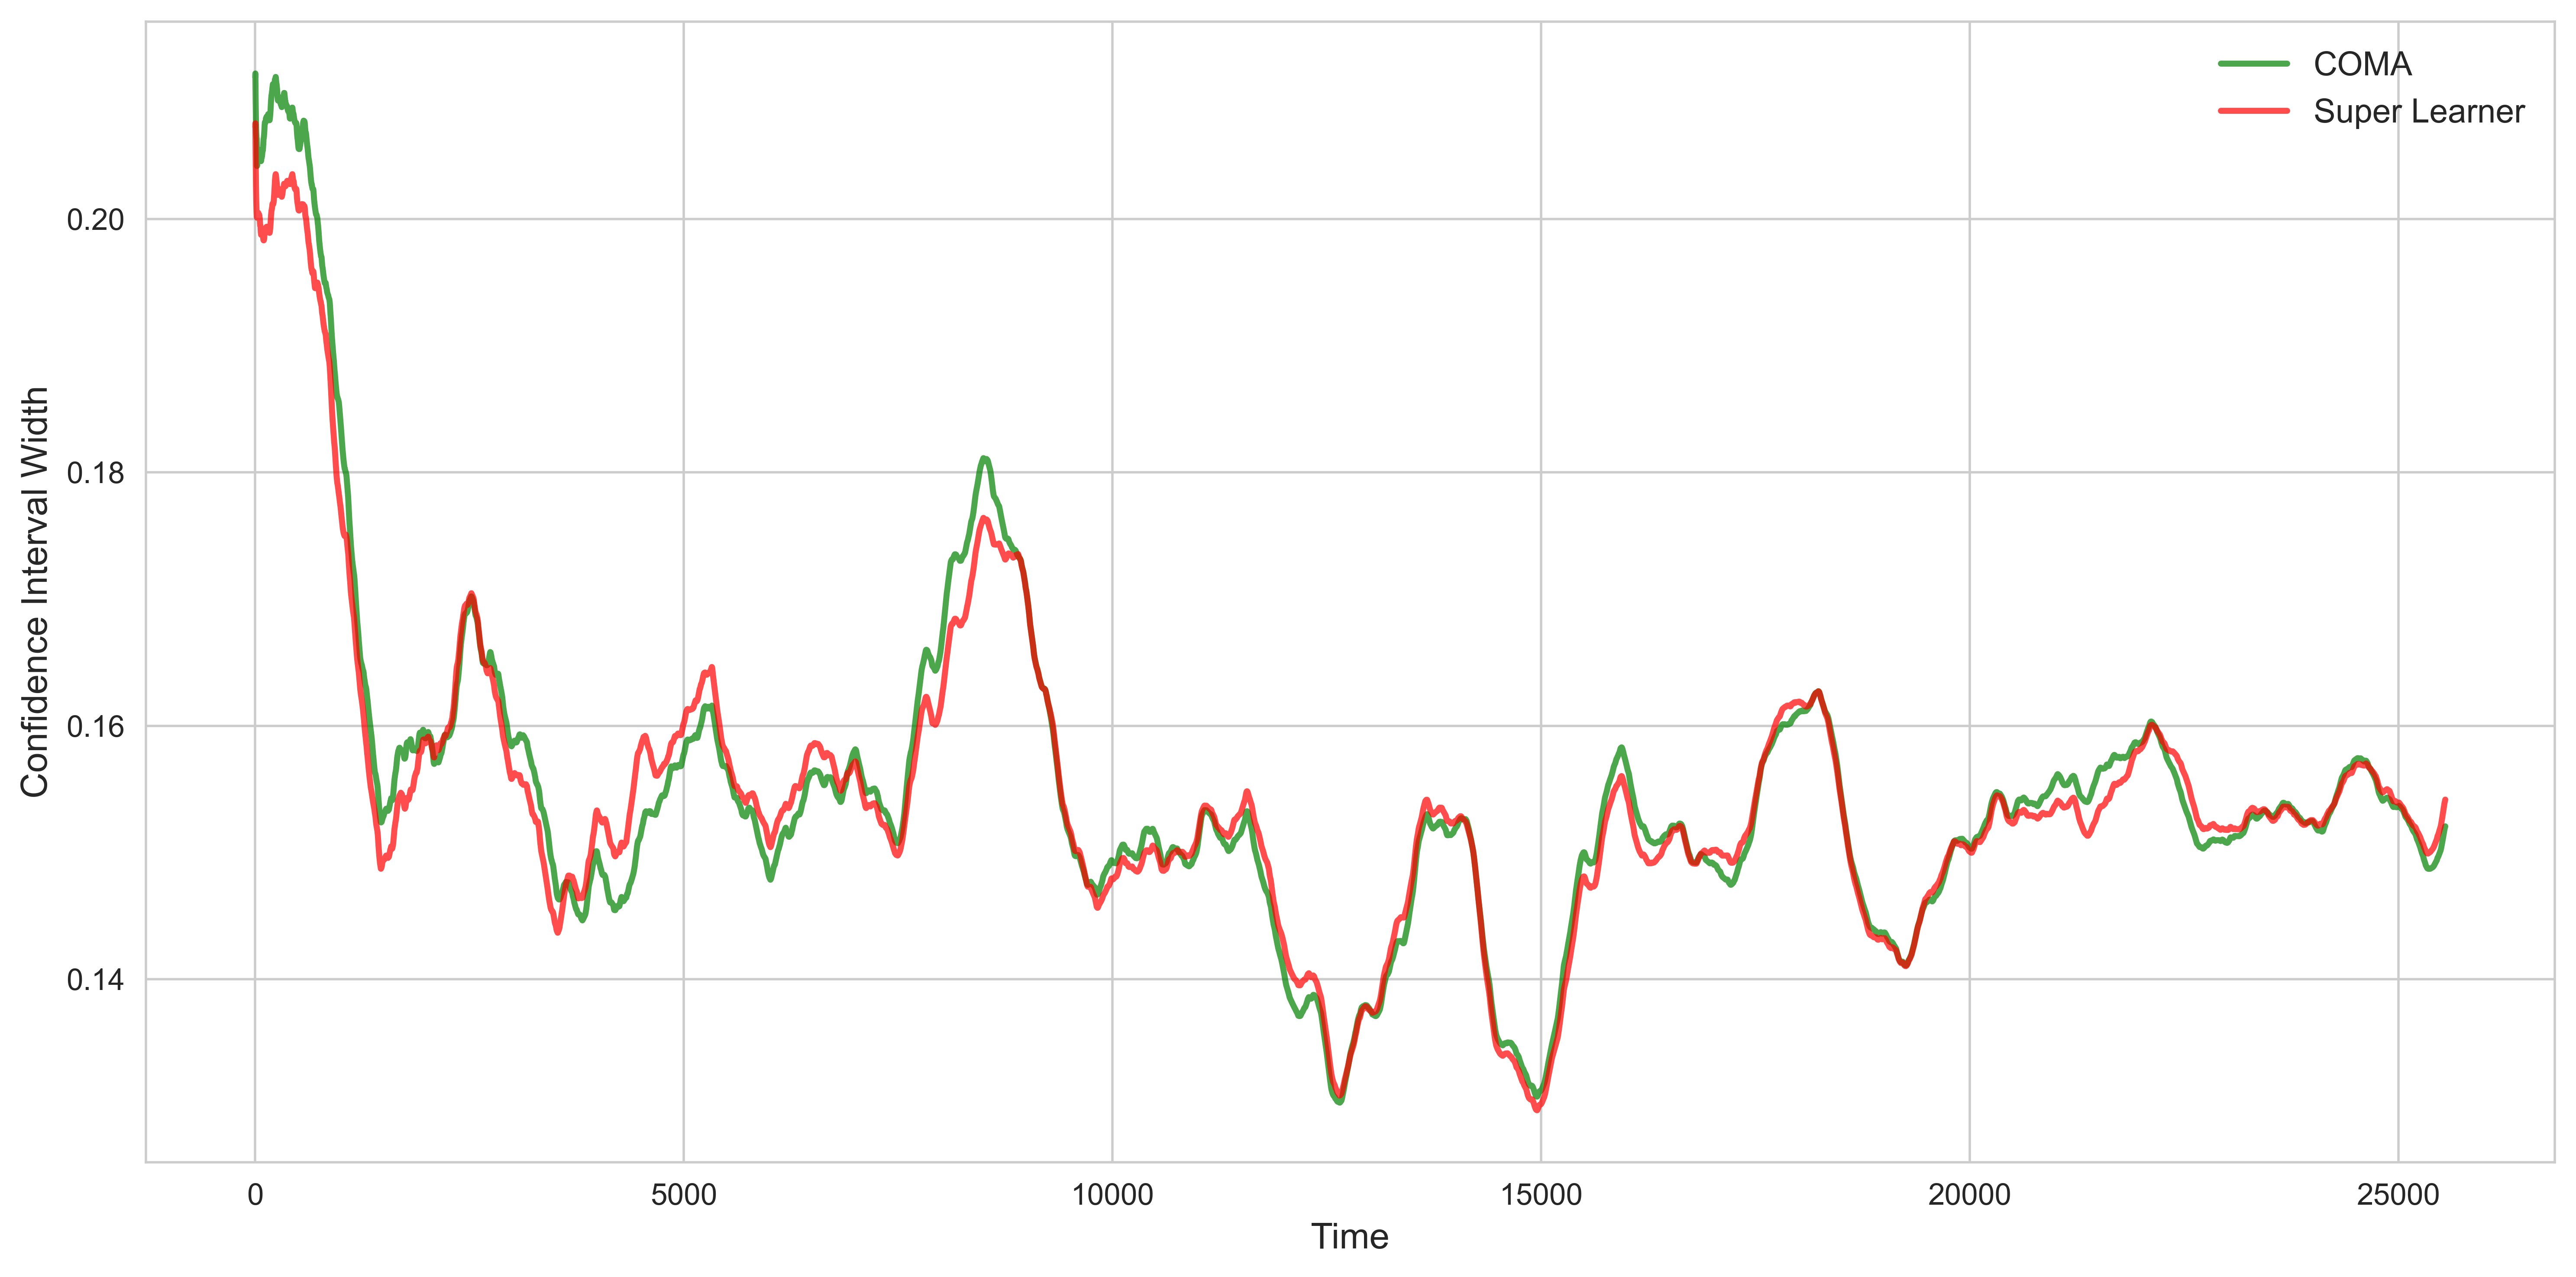

In [98]:
# smooth 

coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
sl_smooth = smooth_series(CI_sl_decaying, window=1000)   

plt.figure(figsize=(12, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA', linewidth=2, alpha = 0.7, color='green')
plt.plot(sl_smooth, label='Super Learner', linewidth=2, alpha = 0.7, color='red')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
#plt.title("ELEC2 (Adahedge, Smoothed): CI Widths — COMA(base) vs Super Learner", fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("elec2_adahedge_smooth_line_base.png", dpi=500, bbox_inches="tight")
plt.show()


Mean ratio: -0.0002843147645651355
Median ratio: -0.011422538646654346
Pr(W_SL < W_COMA): 65.08193633452628
Pr(W_SL = W_COMA): 0.0


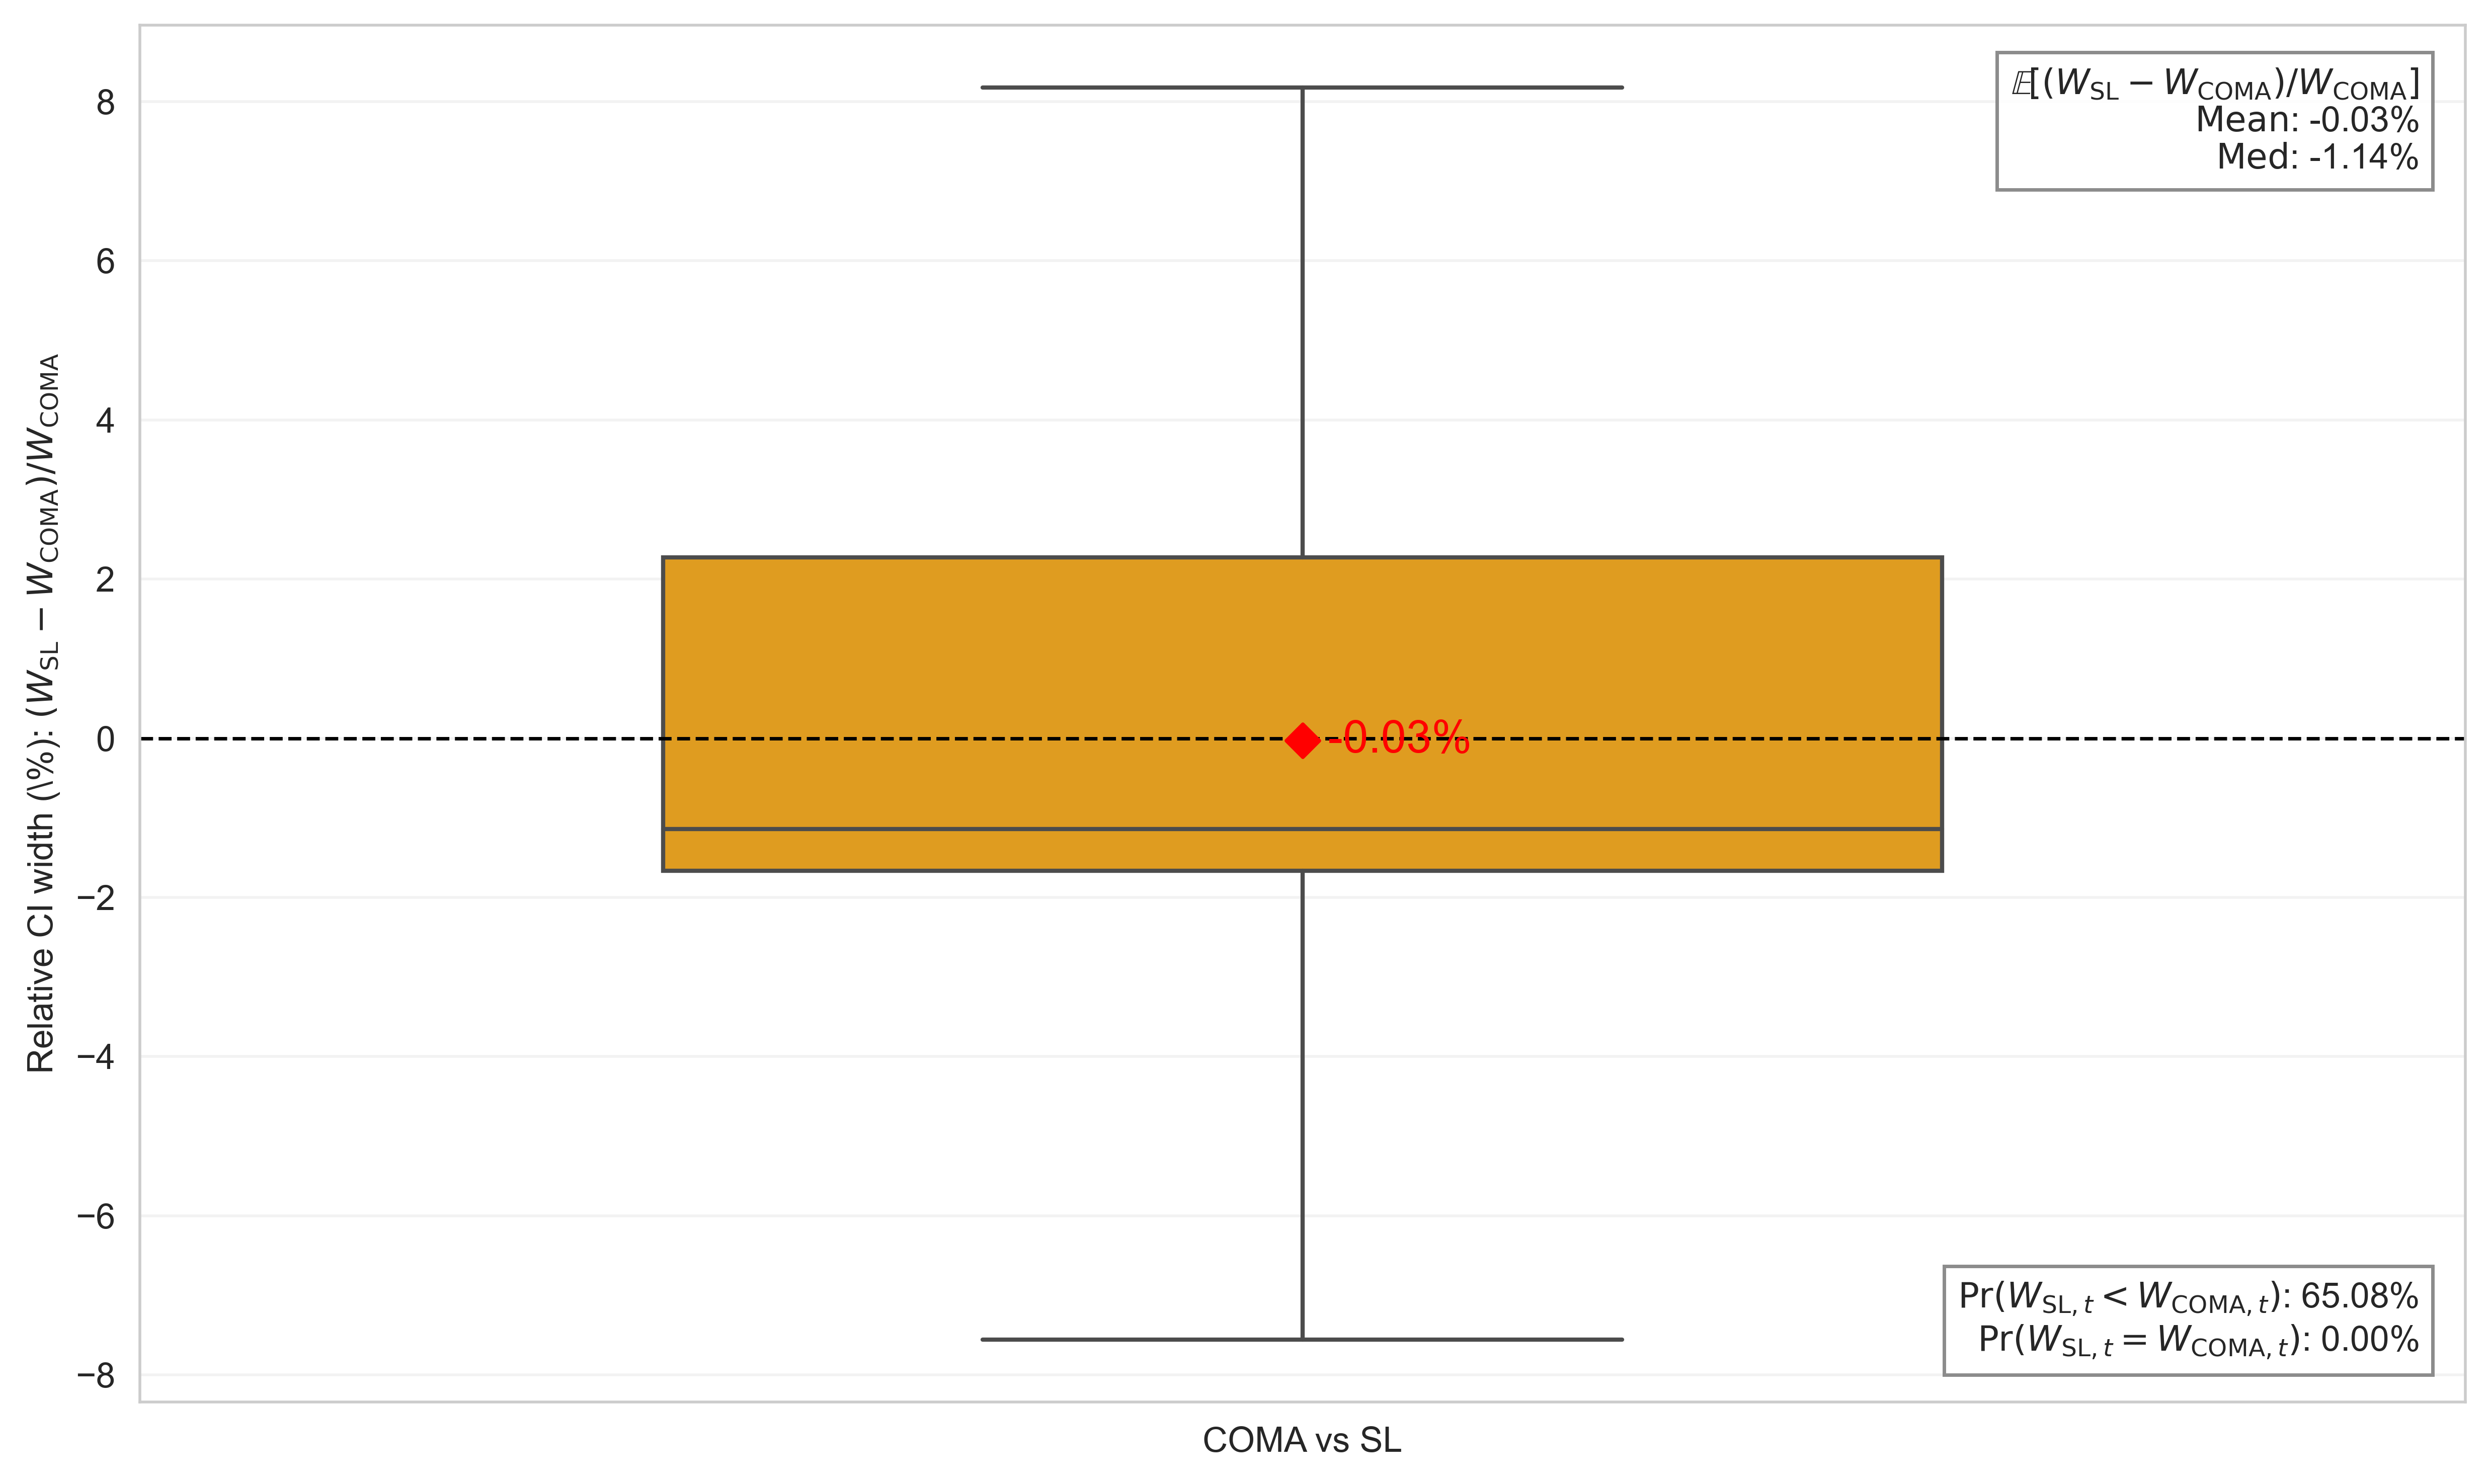

In [99]:

coma_rand = np.asarray(coma_width_rand, dtype=float)
sl = np.asarray(CI_sl_decaying, dtype=float)

T = min(len(coma_rand), len(sl))
coma_rand, sl = coma_rand[:T], sl[:T]

valid_rand = coma_rand > 0
ratio_rand = (sl[valid_rand] - coma_rand[valid_rand]) / coma_rand[valid_rand]

mean_ratio_rand   = np.mean(ratio_rand)
median_ratio_rand = np.median(ratio_rand)

# Optional: tie rate on widths (not ratio) — comment out if you already computed it elsewhere
diff_rand = sl[valid_rand] - coma_rand[valid_rand]
pct_equal_rand = np.mean(np.isclose(diff_rand, 0, atol=1e-8)) * 100
pct_shorter_rand = np.mean(diff_rand < 0) * 100

print("Mean ratio:", mean_ratio_rand)
print("Median ratio:", median_ratio_rand)
print("Pr(W_SL < W_COMA):", pct_shorter_rand)
print("Pr(W_SL = W_COMA):", pct_equal_rand)

df_ratio = pd.DataFrame({
    "Method": ["COMA vs SL"] * len(ratio_rand),
    "Relative CI Width (%)": ratio_rand * 100
})

plt.figure(figsize=(10, 6), dpi=500)
ax = sns.boxplot(
    x="Method",
    y="Relative CI Width (%)",
    data=df_ratio,
    showfliers=False,
    width=0.55,
    linewidth=1.2,
    color="orange"
)

mean_pct = mean_ratio_rand * 100
ax.scatter(0, mean_pct, color="red", marker="D", s=45, zorder=3)
ax.text(0, mean_pct, f"  {mean_pct:.2f}%", color="red", va="center", fontsize=13)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.yaxis.grid(True, alpha=0.25)
ax.xaxis.grid(False)

ax.set_xlabel("")
ax.set_ylabel(r"Relative CI width (\%): $(W_{\mathrm{SL}}-W_{\mathrm{COMA}})/W_{\mathrm{COMA}}$")

annotation_mean = (
    r"$\mathbb{E}\!\left[(W_{\mathrm{SL}}-W_{\mathrm{COMA}})/W_{\mathrm{COMA}}\right]$" "\n"
    r"$\mathrm{Mean}$" f": {mean_ratio_rand*100:.2f}%""\n"
    r"$\mathrm{Med}$" f": {median_ratio_rand*100:.2f}%"
)
ax.text(
    0.98, 0.97, annotation_mean,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

annotation_freq = (
    r"$\Pr(W_{\mathrm{SL},t}<W_{\mathrm{COMA},t})$" f": {pct_shorter_rand:.2f}%\n"
    r"$\Pr(W_{\mathrm{SL},t}=W_{\mathrm{COMA},t})$" f": {pct_equal_rand:.2f}%"
)
ax.text(
    0.98, 0.03, annotation_freq,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

plt.tight_layout()
plt.savefig("elec2_adahedge_boxplot_ratiodiff.png", dpi=500, bbox_inches="tight")
plt.show()

## Hedge 

Mean coverage (COMA): 0.8967452723574173
Mean CI width — COMA: 0.15404012607763795


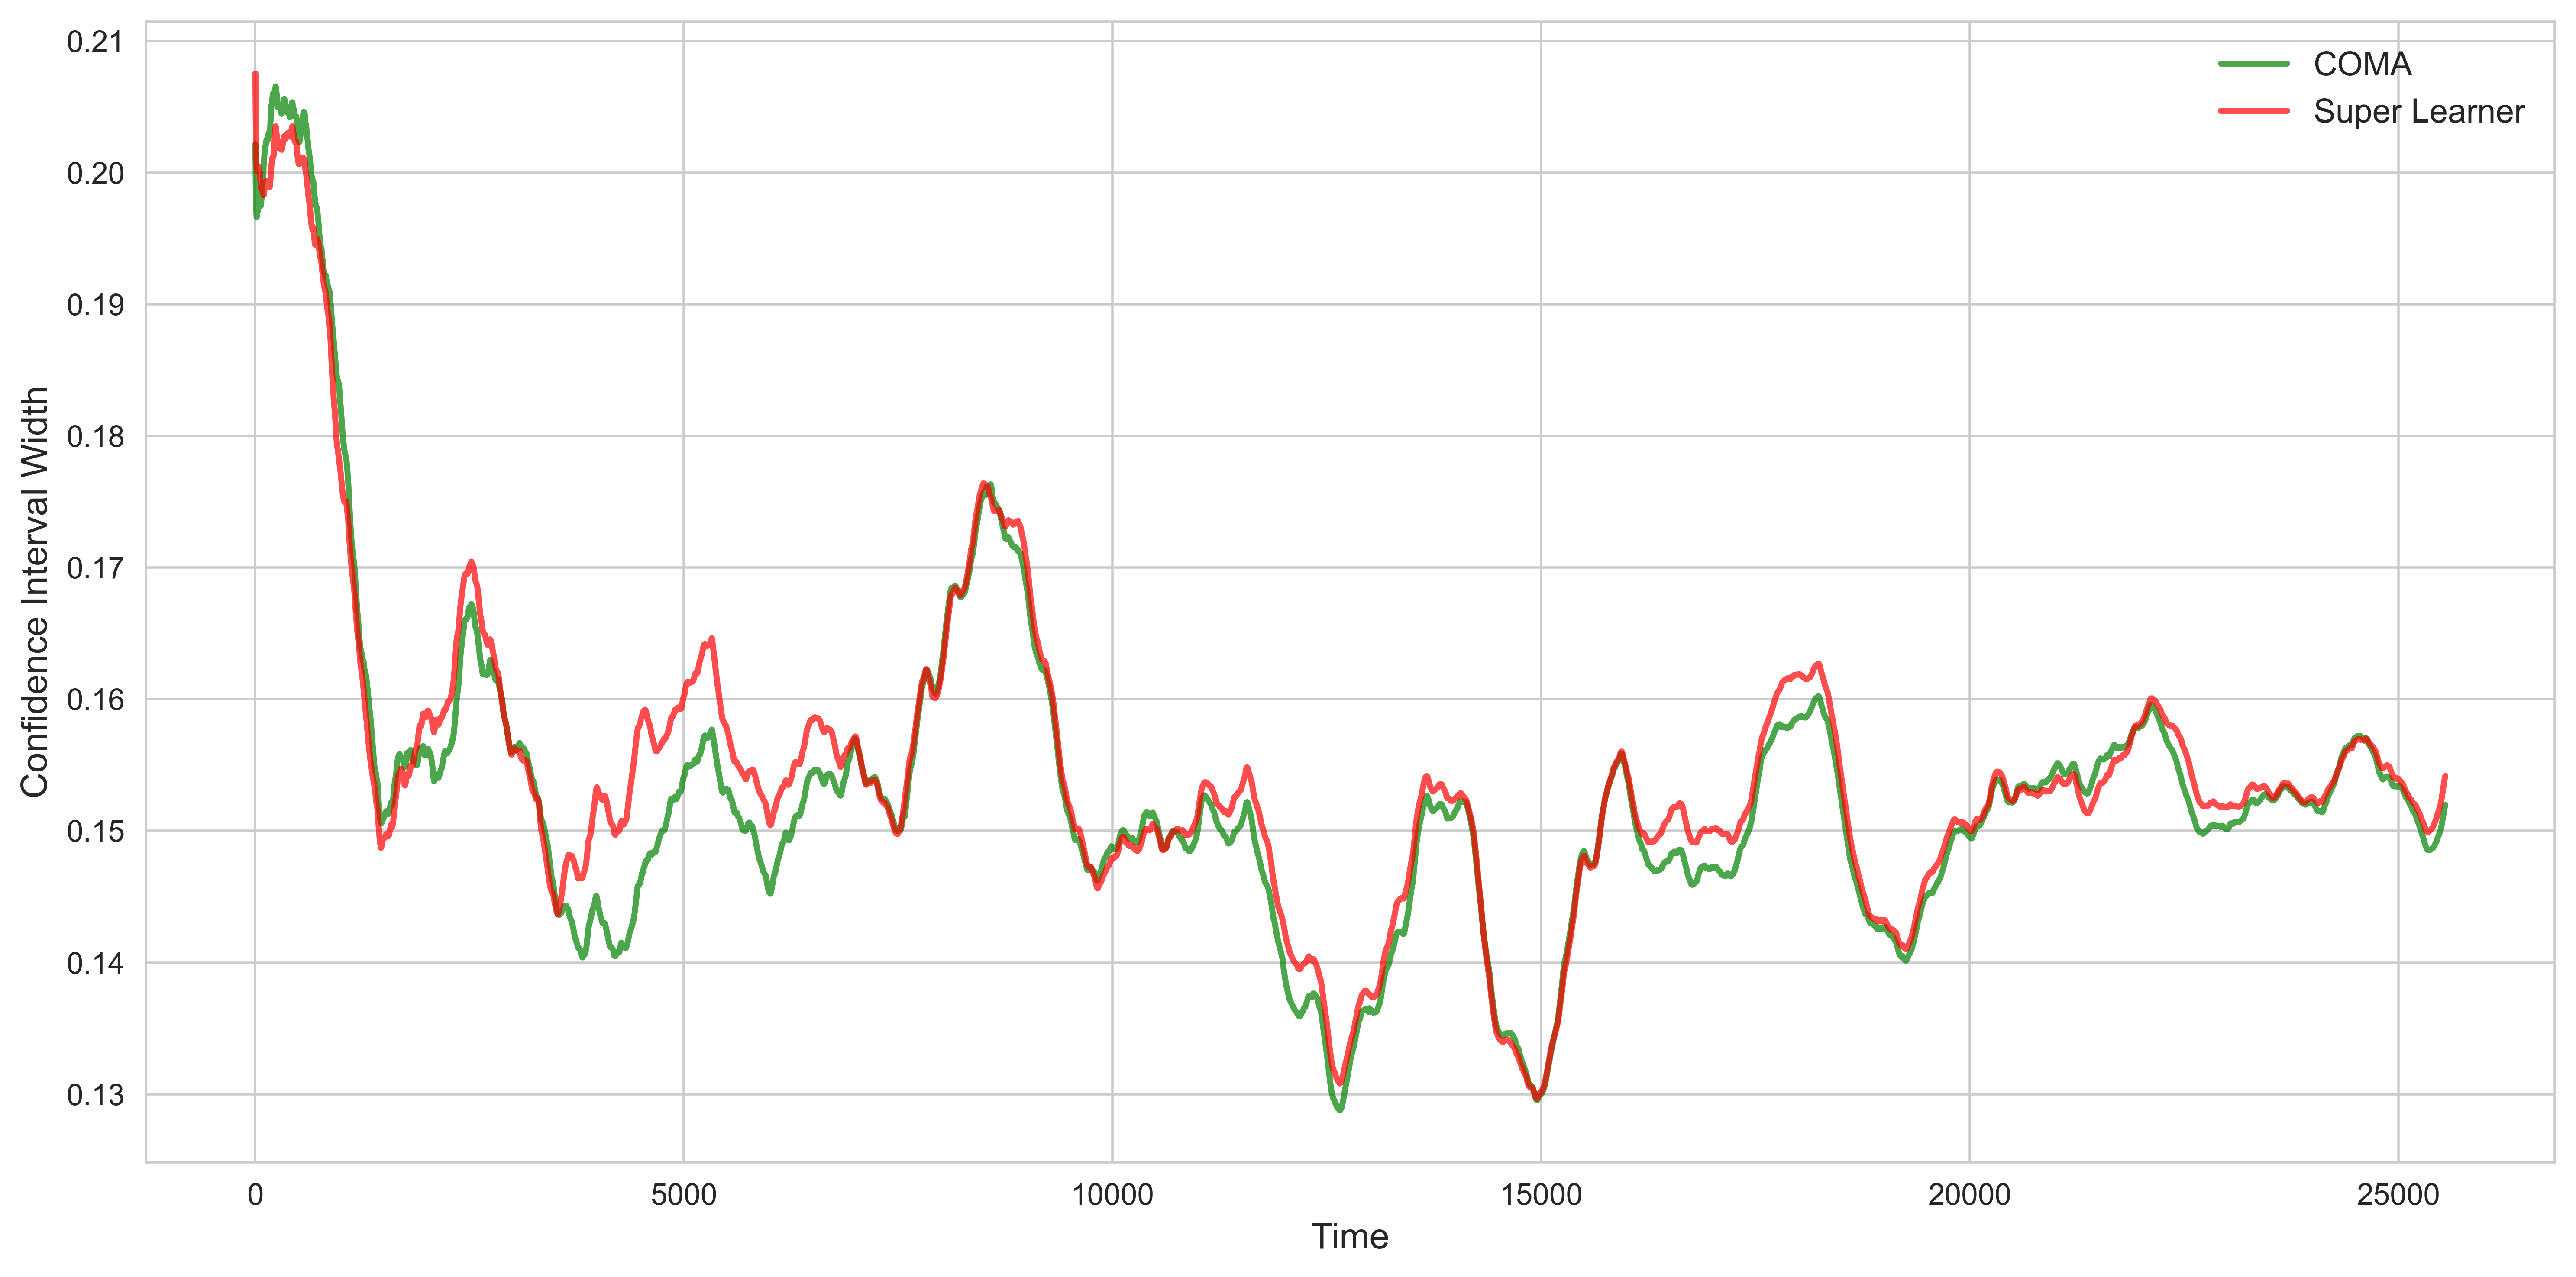

Mean ratio: 0.013355623088475498
Median ratio: -0.004032783876396979
Pr(W_SL < W_COMA): 53.72791319745319
Pr(W_SL = W_COMA): 0.0


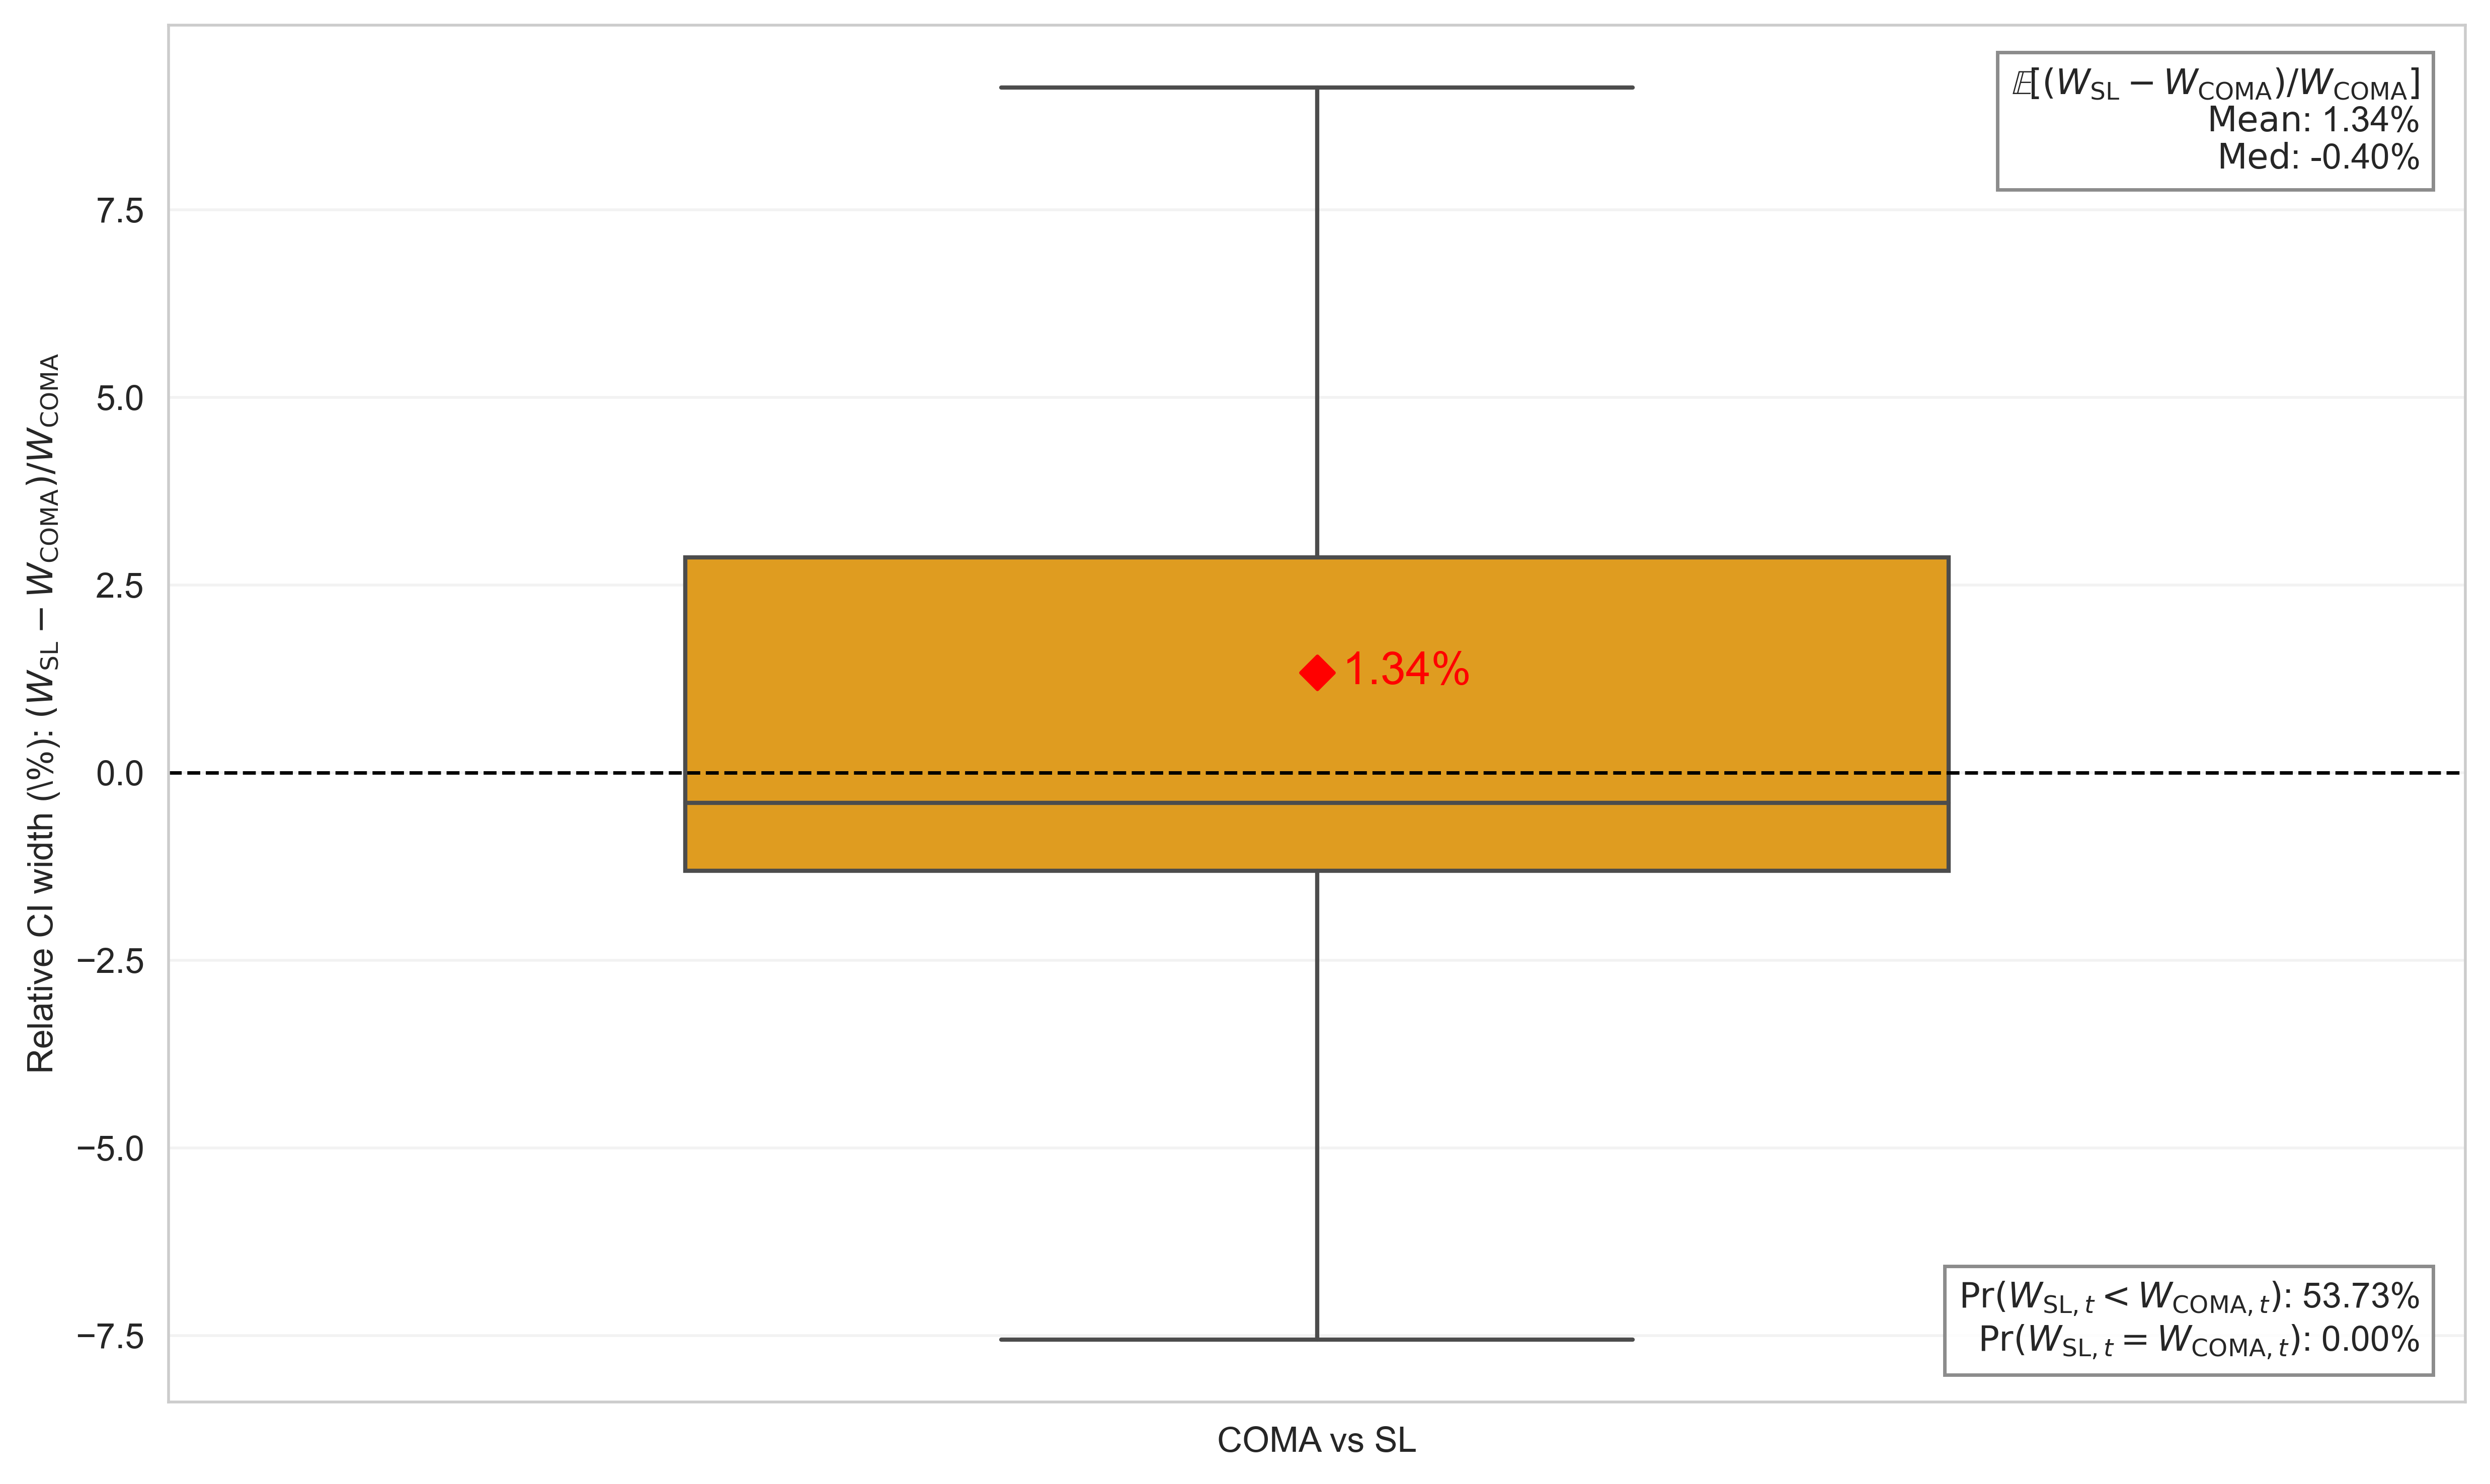

SL shorter than COMA with Hedge: 14262/26546 = 53.73%
Pr(W_SL = W_COMA): 0/26546 = 0.00%


In [100]:

hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)

weights_base = hedAlg_base["weights"]

N_base, K_base = weights_base.shape

min_len = min(len(elec_y[tinit:]), N_base)
y_test_aligned = elec_y[tinit:][-min_len:]

pi_wm_base = []
wm_cov_base = np.full(min_len, np.nan)

for i in range(min_len):
    # Base (3 experts) 
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(len(intervals_list_plain))])
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=np.random.uniform(0.5, 1.0))

    pi_wm_base.append(wmaj_int_base)
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])


print("Mean coverage (COMA):", np.nanmean(wm_cov_base))
print("Mean CI width — COMA:", np.nanmean(coma_width_rand))


data_dict = {
    "COMA\nRand": coma_width_rand,
    "Super\nLearner": CI_sl_decaying
}

df_box = pd.DataFrame({k: pd.Series(v) for k, v in data_dict.items()})
df_long = df_box.melt(var_name="Method", value_name="CI Width")

method_order = ["COMA\nRand", "Super\nLearner"]
df_long["Method"] = pd.Categorical(df_long["Method"], categories=method_order, ordered=True)

palette = {
    "COMA\nRand": "orange",
    "Super\nLearner": "seagreen"
}

# smooth 
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
sl_smooth = smooth_series(CI_sl_decaying, window=1000)   

plt.figure(figsize=(12, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA', linewidth=2, alpha = 0.7, color='green')
plt.plot(sl_smooth, label='Super Learner', linewidth=2, alpha = 0.7, color='red')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
#plt.title("ELEC2 (Hedge, Smoothed): CI Widths — COMA(base) vs Super Learner", fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("elec2_hedge_smooth_line_base.png", dpi=500, bbox_inches="tight")
plt.show()

# boxplot
coma_rand = np.asarray(coma_width_rand, dtype=float)
sl = np.asarray(CI_sl_decaying, dtype=float)
T = min(len(coma_rand), len(sl))
coma_rand, sl = coma_rand[:T], sl[:T]

valid_rand = coma_rand > 0
ratio_rand = (sl[valid_rand] - coma_rand[valid_rand]) / coma_rand[valid_rand]

mean_ratio_rand   = np.mean(ratio_rand)
median_ratio_rand = np.median(ratio_rand)

diff_rand = sl[valid_rand] - coma_rand[valid_rand]
pct_equal_rand = np.mean(np.isclose(diff_rand, 0, atol=1e-8)) * 100
pct_shorter_rand = np.mean(diff_rand < 0) * 100

print("Mean ratio:", mean_ratio_rand)
print("Median ratio:", median_ratio_rand)
print("Pr(W_SL < W_COMA):", pct_shorter_rand)
print("Pr(W_SL = W_COMA):", pct_equal_rand)

df_ratio = pd.DataFrame({
    "Method": ["COMA vs SL"] * len(ratio_rand),
    "Relative CI Width (%)": ratio_rand * 100
})

plt.figure(figsize=(10, 6), dpi=500)
ax = sns.boxplot(
    x="Method",
    y="Relative CI Width (%)",
    data=df_ratio,
    showfliers=False,
    width=0.55,
    linewidth=1.2,
    color="orange"
)

mean_pct = mean_ratio_rand * 100
ax.scatter(0, mean_pct, color="red", marker="D", s=45, zorder=3)
ax.text(0, mean_pct, f"  {mean_pct:.2f}%", color="red", va="center", fontsize=13)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.yaxis.grid(True, alpha=0.25)
ax.xaxis.grid(False)

ax.set_xlabel("")
ax.set_ylabel(r"Relative CI width (\%): $(W_{\mathrm{SL}}-W_{\mathrm{COMA}})/W_{\mathrm{COMA}}$")

annotation_mean = (
    r"$\mathbb{E}\!\left[(W_{\mathrm{SL}}-W_{\mathrm{COMA}})/W_{\mathrm{COMA}}\right]$" "\n"
    r"$\mathrm{Mean}$" f": {mean_ratio_rand*100:.2f}%""\n"
    r"$\mathrm{Med}$" f": {median_ratio_rand*100:.2f}%"
)
ax.text(
    0.98, 0.97, annotation_mean,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

annotation_freq = (
    r"$\Pr(W_{\mathrm{SL},t}<W_{\mathrm{COMA},t})$" f": {pct_shorter_rand:.2f}%\n"
    r"$\Pr(W_{\mathrm{SL},t}=W_{\mathrm{COMA},t})$" f": {pct_equal_rand:.2f}%"
)
ax.text(
    0.98, 0.03, annotation_freq,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
)

plt.tight_layout()
plt.savefig("elec2_hedge_boxplot_ratiodiff.png", dpi=500, bbox_inches="tight")
plt.show()


# comparison SL v.s. COMA base 
#coma_det = np.asarray(coma_width_det)
coma_rand = np.asarray(coma_width_rand)
sl = np.asarray(CI_super_decaying)

# diff
#diff_det = sl - coma_det
diff_rand = sl - coma_rand

# count
#n_shorter_det = np.sum(diff_det < 0)
n_shorter_rand = np.sum(diff_rand < 0)
n_equal_rand  = np.sum(diff_rand == 0)
T = len(coma_width_rand)

# percentage
pct_shorter_rand = n_shorter_rand / T * 100
pct_equal_rand   = n_equal_rand / T * 100

print(f"SL shorter than COMA with Hedge: {n_shorter_rand}/{T} = {pct_shorter_rand:.2f}%")
print(f"Pr(W_SL = W_COMA): {n_equal_rand}/{T} = {pct_equal_rand:.2f}%")